In [1]:
# ============================================================
# Celda 1 — Carga del dataset
# Fuente: U.S. Bureau of Labor Statistics, Current Employment Statistics (CES)
# Vía FRED (Federal Reserve Bank of St. Louis)
# Series:
#   - PAYNSA: All Employees, Total Nonfarm, NOT Seasonally Adjusted
#   - PAYEMS: All Employees, Total Nonfarm, Seasonally Adjusted (referencia)
# ============================================================
import pandas as pd

url_nsa = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=PAYNSA"
url_sa  = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=PAYEMS"

df_nsa = pd.read_csv(url_nsa, parse_dates=["observation_date"])
df_sa  = pd.read_csv(url_sa,  parse_dates=["observation_date"])

df_nsa = df_nsa.rename(columns={"observation_date": "fecha", "PAYNSA": "empleo_nsa"})
df_sa  = df_sa.rename(columns={"observation_date": "fecha", "PAYEMS": "empleo_sa"})

df = df_nsa.merge(df_sa, on="fecha", how="inner")
df = df.set_index("fecha").sort_index()

# Inspección rápida
print("Rango temporal:", df.index.min().date(), "→", df.index.max().date())
print("Total de observaciones:", len(df))
print("Frecuencia detectada:", pd.infer_freq(df.index))
print("\nPrimeras filas:")
print(df.head())
print("\nÚltimas filas:")
print(df.tail())
print("\nValores faltantes:")
print(df.isnull().sum())
print("\nUnidad: miles de personas empleadas")

Rango temporal: 1939-01-01 → 2026-03-01
Total de observaciones: 1047
Frecuencia detectada: MS

Primeras filas:
            empleo_nsa  empleo_sa
fecha                            
1939-01-01       29296      29923
1939-02-01       29394      30100
1939-03-01       29804      30280
1939-04-01       29786      30094
1939-05-01       30145      30299

Últimas filas:
            empleo_nsa  empleo_sa
fecha                            
2025-11-01      159571     158449
2025-12-01      159358     158432
2026-01-01      156728     158592
2026-02-01      157204     158459
2026-03-01      157775     158637

Valores faltantes:
empleo_nsa    0
empleo_sa     0
dtype: int64

Unidad: miles de personas empleadas


In [12]:
# ============================================================
# Celda 0 — Instalación de dependencias
# ============================================================
!pip install prophet --quiet
print("✅ Prophet instalado")

✅ Prophet instalado


# Análisis y Pronóstico del Empleo Total No Agrícola de Estados Unidos (1939–2026)

**Trabajo final – Estadística Aplicada**
**Maestría en Ciencia de Datos – Universidad Pontificia Bolivariana**
**Autor:** Sebastián Velasco Ardila

---

## 1. Introducción al análisis de series de tiempo

### 1.1 Fenómeno a estudiar

El presente trabajo aborda el comportamiento del **empleo total no agrícola de Estados Unidos** (*Total Nonfarm Payroll Employment*), uno de los indicadores macroeconómicos más relevantes a nivel mundial. La serie cuantifica, mes a mes, el número total de personas empleadas en establecimientos no agrícolas del país, y es publicada mensualmente por el **Bureau of Labor Statistics (BLS)** a través del programa *Current Employment Statistics (CES)*.

La fuente utilizada es la base de datos **FRED** (Federal Reserve Economic Data) del Banco de la Reserva Federal de San Luis, que distribuye públicamente la serie con código **PAYNSA** (versión sin ajuste estacional) desde enero de 1939 hasta la fecha. Se utiliza adicionalmente la serie **PAYEMS** (versión con ajuste estacional oficial del BLS) como referencia comparativa.

### 1.2 Motivación

El estudio del empleo nonfarm es relevante por tres razones principales:

1. **Relevancia macroeconómica.** El reporte mensual de empleo es considerado el indicador económico más observado a nivel global. Su publicación, conocida como *Jobs Report*, mueve los mercados financieros internacionales y orienta las decisiones de política monetaria de la Reserva Federal.

2. **Riqueza estadística.** Con 87 años de observaciones mensuales (más de 1.000 puntos), la serie ofrece un caso de estudio excepcional para el análisis de series de tiempo. Presenta una **tendencia secular creciente**, una **estacionalidad mensual marcada** asociada al ciclo del consumo y al calendario escolar, y al menos tres **shocks estructurales** documentados: la recesión de 2001, la crisis financiera de 2008 y la pandemia de COVID-19 en 2020.

3. **Aplicabilidad metodológica.** Las técnicas desarrolladas en este trabajo —descomposición STL, modelado SARIMA y evaluación mediante ventana de validación— son trasladables a cualquier serie de empleo nacional, incluidas las publicadas por el DANE para el caso colombiano.

### 1.3 Objetivos

**Objetivo general.** Modelar y pronosticar la serie mensual de empleo total no agrícola de Estados Unidos mediante un modelo estadístico que capture su componente tendencial y estacional, a partir de los datos históricos publicados por el BLS.

**Objetivos específicos:**
- Caracterizar la serie mediante análisis exploratorio, identificando tendencia, estacionalidad y patrones atípicos.
- Aplicar pruebas de estacionariedad y descomposición de la serie.
- Ajustar un modelo SARIMA adecuado utilizando la librería `statsmodels`.
- Generar pronósticos para un horizonte definido y evaluar su calidad mediante métricas estándar (MAE, RMSE, MAPE).

### 1.4 Pregunta de investigación

> *¿Es posible construir un modelo SARIMA que represente adecuadamente la dinámica mensual del empleo total no agrícola de Estados Unidos y genere pronósticos confiables, considerando la presencia de estacionalidad y shocks estructurales en la serie?*

## 2. Exploración de la Base de Datos

### 2.1 Aspectos identificables mediante la visualización de una serie de tiempo

La visualización gráfica de una serie de tiempo permite identificar de forma intuitiva sus componentes estructurales antes de aplicar cualquier modelo formal. A continuación se describen los principales aspectos que pueden detectarse visualmente:

1. **Tendencia (*trend*).** Es el componente de largo plazo que refleja la dirección general de la serie a lo largo del tiempo. Puede ser creciente, decreciente o estable, y suele asociarse a factores estructurales como el crecimiento poblacional, el desarrollo económico o cambios tecnológicos. En el caso del empleo nonfarm, se espera una tendencia creciente reflejo de la expansión histórica de la economía estadounidense.

2. **Estacionalidad (*seasonality*).** Corresponde a fluctuaciones que se repiten con un periodo fijo y conocido (mensual, trimestral, anual). Estas oscilaciones se asocian a factores recurrentes como el clima, las festividades, los ciclos escolares o las temporadas comerciales. Visualmente, se manifiestan como patrones repetitivos a lo largo del tiempo.

3. **Patrones irregulares y *outliers*.** Son desviaciones abruptas e inesperadas respecto al comportamiento histórico, generalmente asociadas a eventos exógenos (crisis económicas, pandemias, conflictos, cambios de política). Su identificación es crucial porque afectan la estimación de modelos paramétricos clásicos.

Aspectos adicionales que pueden inferirse: la presencia de **ciclos** (oscilaciones de periodo no fijo, como los ciclos económicos), cambios en la **varianza** (heterocedasticidad) y posibles **quiebres estructurales** (cambios de régimen).

### 2.2 Variables disponibles y naturaleza de los datos

La base de datos utilizada contiene **dos series temporales mensuales** publicadas por el Bureau of Labor Statistics (BLS) y distribuidas a través de FRED:

| Variable | Código FRED | Descripción | Unidad | Ajuste estacional |
|---|---|---|---|---|
| `empleo_nsa` | PAYNSA | All Employees, Total Nonfarm | Miles de personas | No ajustada |
| `empleo_sa` | PAYEMS | All Employees, Total Nonfarm | Miles de personas | Ajustada por BLS |

**Naturaleza de los datos:**

- **Tipo de serie:** Univariada en el caso del modelado (se trabajará con `empleo_nsa`), con una variable de referencia (`empleo_sa`).
- **Frecuencia:** Mensual (`MS` — *month start*), con observaciones tomadas el primer día de cada mes.
- **Periodo cubierto:** Enero de 1939 a marzo de 2026 (1.047 observaciones).
- **Tipo de variable:** Cuantitativa continua (medida en miles de personas).
- **Fuente original:** *Current Employment Statistics (CES) Survey* del BLS, encuesta mensual aplicada a aproximadamente 119.000 establecimientos representativos de 622.000 sitios de trabajo.
- **Calidad:** Sin valores faltantes; serie oficial revisada anualmente mediante *benchmarking* con la *Quarterly Census of Employment and Wages (QCEW)*.

**Justificación del uso de PAYNSA como variable de interés.** Para los efectos del análisis de series de tiempo y, en particular, del modelado de la **estacionalidad**, se selecciona la versión **sin ajuste estacional (PAYNSA)**. Esto permite que el modelo SARIMA capture explícitamente el componente estacional de la serie, que de otra forma estaría removido por el ajuste oficial del BLS. La versión ajustada (PAYEMS) se conserva como serie de referencia para validar el componente estacional estimado por el modelo.

### 2.3 Análisis exploratorio de los datos

Una serie de tiempo permite aplicar diversos análisis estadísticos orientados a comprender su estructura interna. Entre los principales se encuentran:

- **Análisis visual:** trazado de la serie en el tiempo, identificación de tendencia, estacionalidad, ciclos y *outliers*.
- **Estadísticas descriptivas:** media, mediana, desviación estándar, valores mínimos y máximos, distribución de frecuencias.
- **Descomposición de la serie:** separación en componentes de tendencia, estacionalidad y residuo (aditiva o multiplicativa, clásica o STL).
- **Análisis de autocorrelación:** funciones ACF y PACF para identificar dependencias temporales.
- **Pruebas de estacionariedad:** test de Dickey-Fuller Aumentado (ADF), test KPSS.
- **Análisis de estabilidad:** evaluación de cambios en media y varianza (homocedasticidad/heterocedasticidad).

En esta sección se aborda principalmente el **análisis visual** y la **descomposición de la serie**. Las pruebas formales de estacionariedad se desarrollan en el Hito 4 como parte de la preparación para el modelado SARIMA.

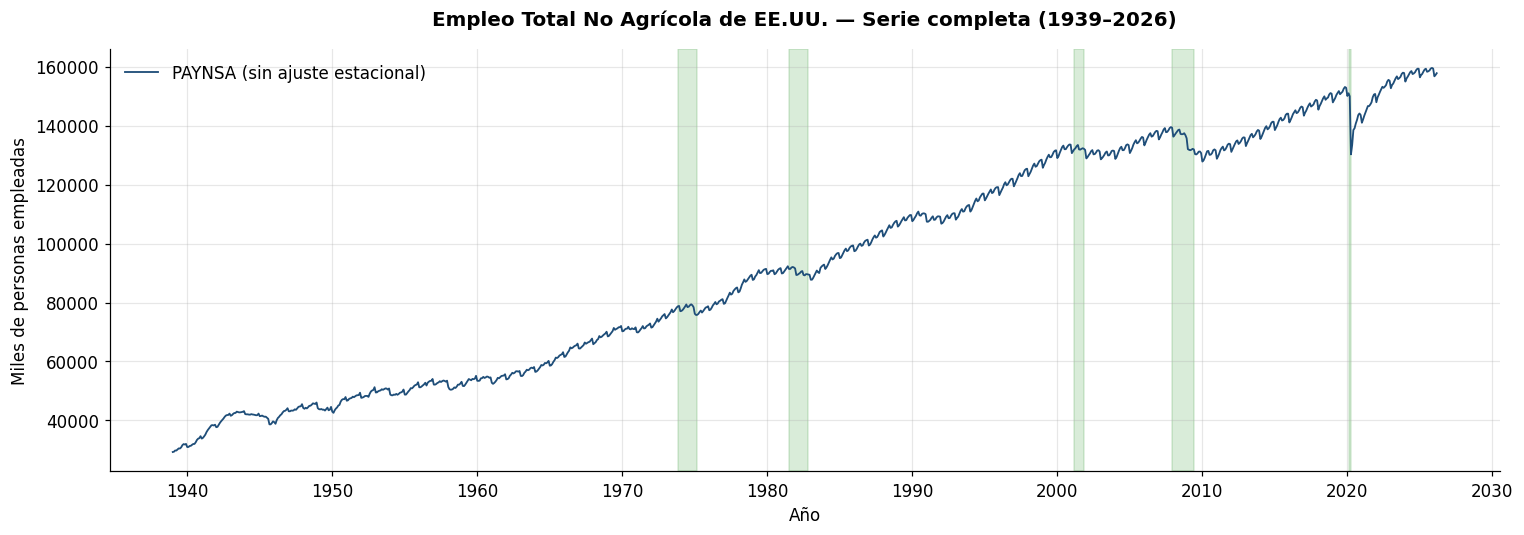

In [3]:
# ============================================================
# Celda 2.3.a — Setup gráfico y serie completa con eventos estructurales
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({
    "figure.figsize": (14, 5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

# Eventos estructurales conocidos (recesiones NBER + COVID)
eventos = [
    ("1973-11", "1975-03", "Crisis del petróleo"),
    ("1981-07", "1982-11", "Recesión Volcker"),
    ("2001-03", "2001-11", "Recesión 2001"),
    ("2007-12", "2009-06", "Gran Recesión"),
    ("2020-02", "2020-04", "COVID-19"),
]

fig, ax = plt.subplots()
ax.plot(df.index, df["empleo_nsa"], color="#1f4e79", linewidth=1.2, label="PAYNSA (sin ajuste estacional)")

# Sombrear periodos de recesión
for inicio, fin, _ in eventos:
    ax.axvspan(pd.Timestamp(inicio), pd.Timestamp(fin), alpha=0.15, color="green")

ax.set_title("Empleo Total No Agrícola de EE.UU. — Serie completa (1939–2026)",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Año")
ax.set_ylabel("Miles de personas empleadas")
ax.xaxis.set_major_locator(mdates.YearLocator(10))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(loc="upper left", frameon=False)

plt.tight_layout()
plt.show()

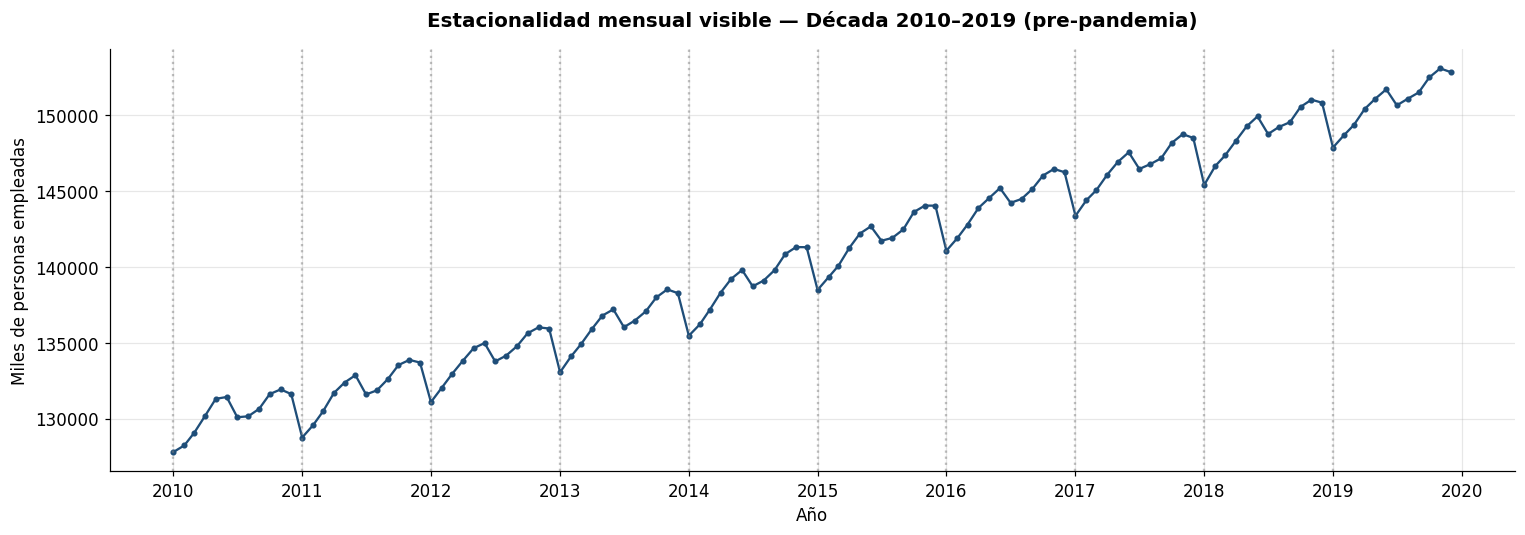

In [4]:
# ============================================================
# Celda 2.3.b — Zoom 2010–2020 para visualizar estacionalidad mensual
# ============================================================
serie_zoom = df.loc["2010-01-01":"2019-12-01", "empleo_nsa"]

fig, ax = plt.subplots()
ax.plot(serie_zoom.index, serie_zoom.values, color="#1f4e79", linewidth=1.5, marker="o", markersize=3)

# Marcar enero de cada año (donde típicamente cae el empleo)
for año in range(2010, 2020):
    ax.axvline(pd.Timestamp(f"{año}-01-01"), color="gray", linestyle=":", alpha=0.5)

ax.set_title("Estacionalidad mensual visible — Década 2010–2019 (pre-pandemia)",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Año")
ax.set_ylabel("Miles de personas empleadas")
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.show()

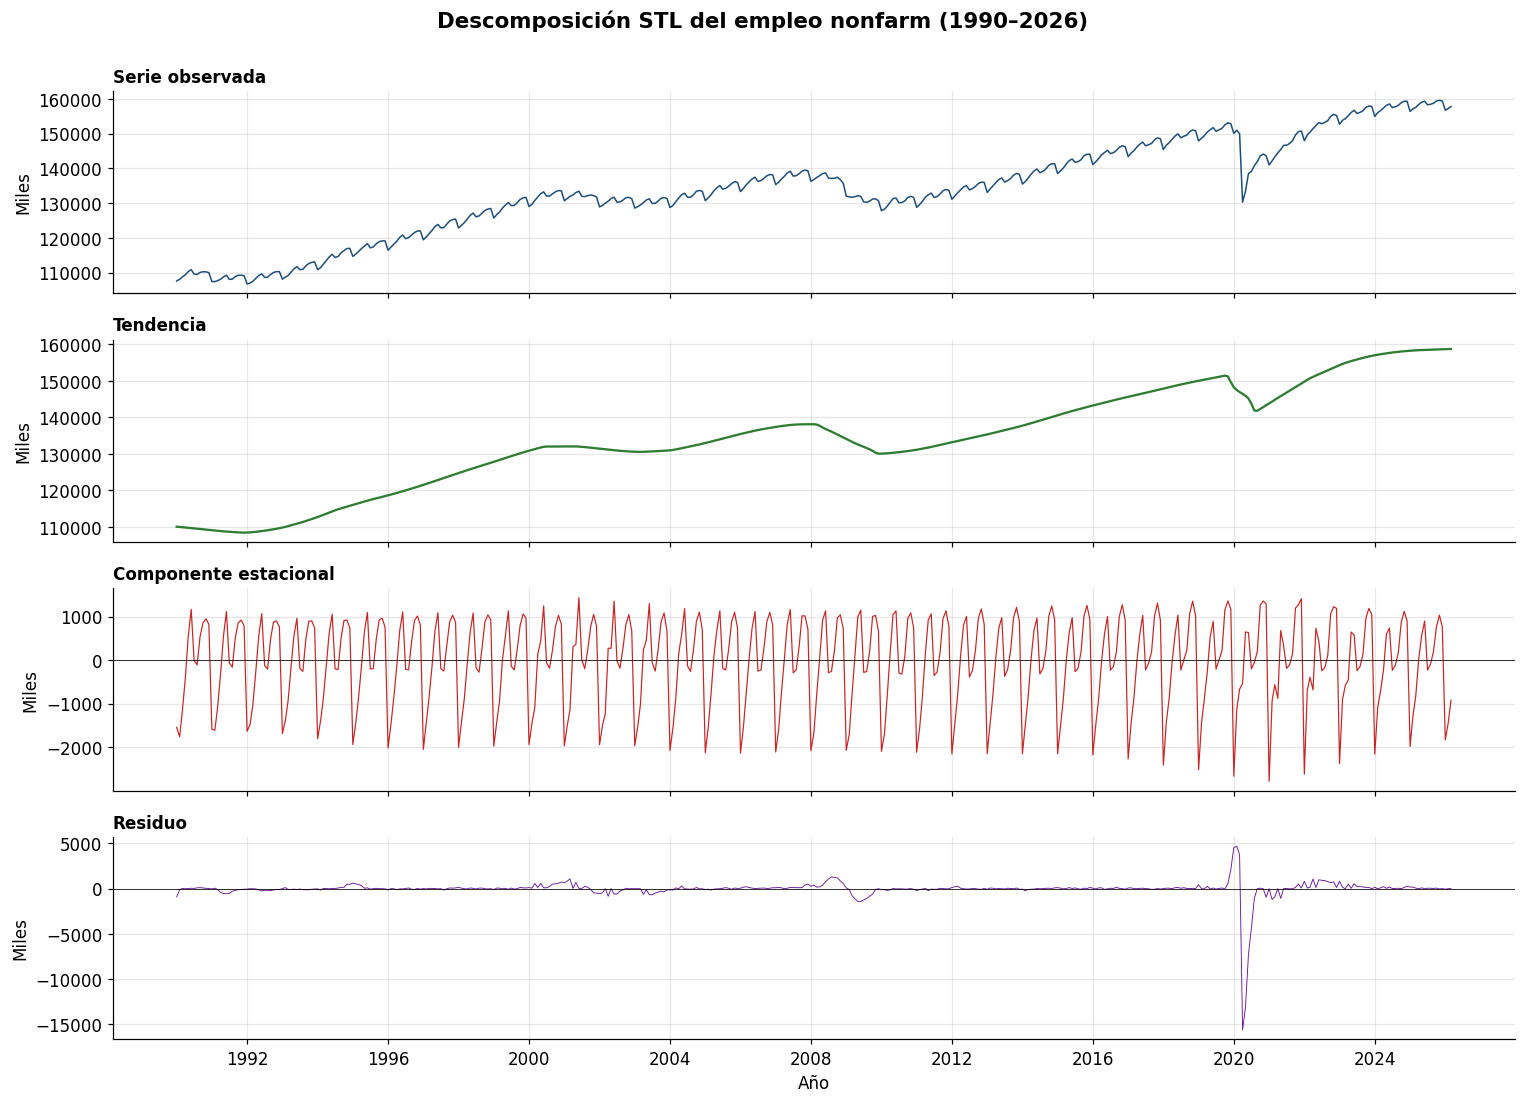


Amplitud del componente estacional: 4,223 miles de personas
Equivale aproximadamente al 3.15% de la media de la serie


In [5]:
# ============================================================
# Celda 2.3.c — Descomposición STL (Seasonal-Trend decomposition using LOESS)
# ============================================================
from statsmodels.tsa.seasonal import STL

# Trabajamos con la serie desde 1990 para una descomposición más interpretable
# (la serie completa abarca regímenes muy diferentes de la economía gringa)
serie_stl = df.loc["1990-01-01":, "empleo_nsa"]

# STL con periodo estacional 12 (mensual)
stl = STL(serie_stl, period=12, robust=True)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(serie_stl.index, serie_stl.values, color="#1f4e79", linewidth=1)
axes[0].set_title("Serie observada", fontsize=11, loc="left", fontweight="bold")
axes[0].set_ylabel("Miles")

axes[1].plot(result.trend.index, result.trend.values, color="#2e7d32", linewidth=1.5)
axes[1].set_title("Tendencia", fontsize=11, loc="left", fontweight="bold")
axes[1].set_ylabel("Miles")

axes[2].plot(result.seasonal.index, result.seasonal.values, color="#c62828", linewidth=0.8)
axes[2].set_title("Componente estacional", fontsize=11, loc="left", fontweight="bold")
axes[2].set_ylabel("Miles")
axes[2].axhline(0, color="black", linewidth=0.5)

axes[3].plot(result.resid.index, result.resid.values, color="#6a1b9a", linewidth=0.6)
axes[3].set_title("Residuo", fontsize=11, loc="left", fontweight="bold")
axes[3].set_ylabel("Miles")
axes[3].axhline(0, color="black", linewidth=0.5)
axes[3].set_xlabel("Año")

plt.suptitle("Descomposición STL del empleo nonfarm (1990–2026)",
             fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

# Magnitud del componente estacional
amplitud_estacional = result.seasonal.max() - result.seasonal.min()
print(f"\nAmplitud del componente estacional: {amplitud_estacional:,.0f} miles de personas")
print(f"Equivale aproximadamente al {amplitud_estacional / serie_stl.mean() * 100:.2f}% de la media de la serie")

**Interpretación de los hallazgos visuales:**

A partir de las visualizaciones se identifican los siguientes patrones:

1. **Tendencia creciente sostenida.** La serie presenta un crecimiento secular desde 1939, pasando de 29.296 mil empleos en enero de 1939 a 157.775 mil en marzo de 2026. Esto representa un crecimiento de aproximadamente **5,4 veces** en 87 años. La pendiente es aproximadamente lineal en términos absolutos durante periodos de expansión, con interrupciones claras durante recesiones.

2. **Estacionalidad mensual marcada.** El acercamiento a la década 2010–2019 revela un patrón anual repetitivo con forma de "dientes de sierra". La descomposición STL confirma una **amplitud del componente estacional de 4.223 mil empleos**, equivalente al **3,15% de la media de la serie**. Aunque en términos relativos la magnitud es modesta, en términos absolutos representa más de 4 millones de personas oscilando estacionalmente cada año, lo que justifica plenamente la inclusión de un componente estacional explícito (SARIMA con periodo s=12).

3. **Shocks estructurales identificables.** La serie evidencia tres rupturas mayores: la Gran Recesión (2008–2009), con pérdida sostenida de empleo; la pandemia de COVID-19 (marzo–abril 2020), con la caída más abrupta en la historia de la serie (más de 22 millones de empleos perdidos en dos meses, visible como el valle de 130.252 mil en el subperiodo 2020-2026); y la recuperación posterior, igualmente atípica en su velocidad. Estos shocks se reflejan claramente como picos en el componente residual de la descomposición STL, sugiriendo la conveniencia de tratar al menos el evento COVID como una intervención exógena en el modelado.

4. **Heterogeneidad de regímenes.** La estructura de la serie cambia notablemente a lo largo del tiempo (industrialización post-guerra, terciarización a partir de los 80, post-crisis 2008, post-pandemia). Por esta razón, el análisis y modelado se centrará en el periodo **1990–2026**, donde la estructura económica es más homogénea y la estacionalidad mensual está claramente establecida.

### 2.4 Estadísticas descriptivas

A continuación se presentan tres niveles de estadísticas descriptivas:

1. **Estadísticas globales** sobre la serie completa.
2. **Estadísticas por subperiodo** para evidenciar el cambio estructural en escala y dispersión a lo largo del tiempo.
3. **Estadísticas mensuales** que permiten cuantificar la estacionalidad identificada visualmente en el Hito 2.3.

1. ESTADÍSTICAS GLOBALES — Serie completa (1939–2026)
count      1047.0
mean      93580.0
std       38771.0
min       29296.0
25%       54286.0
50%       91157.0
75%      131610.0
max      159571.0

Coeficiente de variación: 41.43%
Asimetría (skewness):     0.047
Curtosis:                 -1.418

2. ESTADÍSTICAS POR SUBPERIODO
                   Periodo   N  Media  Mediana  Desv. Est.    Mín    Máx  CV (%)
   1939–1959 (post-guerra) 252  44855    44594        6417  29296  55124   14.31
     1960–1979 (expansión) 240  69797    70790       10742  52414  91415   15.39
1980–1999 (terciarización) 240 106828   107888       12139  87729 131633   11.36
  2000–2019 (pre-pandemia) 240 136904   135262        6458 127804 153094    4.72
    2020–2026 (post-COVID)  75 152371   154942        6753 130252 159571    4.43

3. ESTADÍSTICAS POR MES — Periodo 1990–2019 (régimen homogéneo)
        Media  Desv. Est.  Desv. vs media anual
mes                                            
Ene  127516.0     11575.

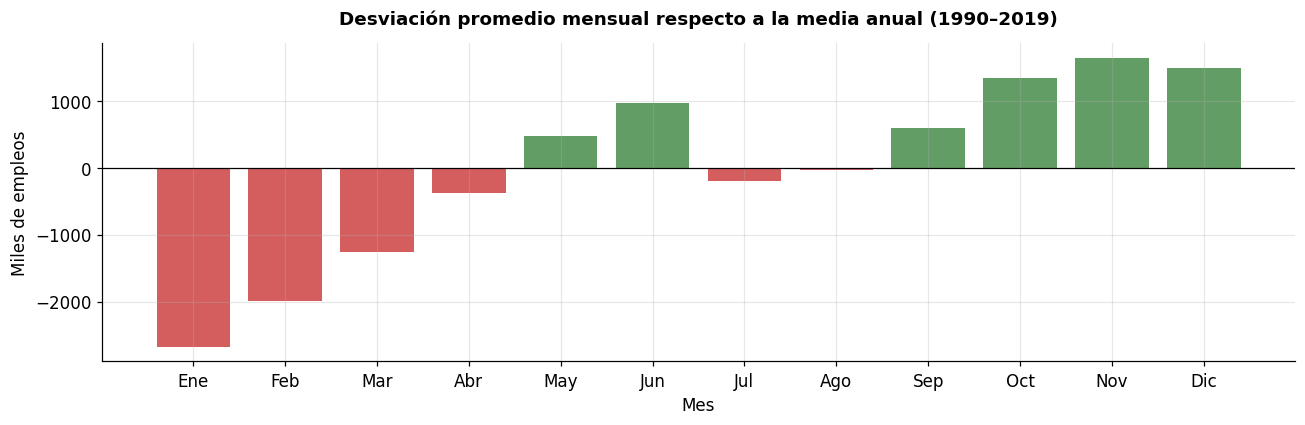

In [6]:
# ============================================================
# Celda 2.4 — Estadísticas descriptivas
# ============================================================
import numpy as np

# ---- 1. Estadísticas globales ----
print("=" * 70)
print("1. ESTADÍSTICAS GLOBALES — Serie completa (1939–2026)")
print("=" * 70)
desc_global = df["empleo_nsa"].describe()
print(desc_global.round(0).to_string())
print(f"\nCoeficiente de variación: {df['empleo_nsa'].std() / df['empleo_nsa'].mean() * 100:.2f}%")
print(f"Asimetría (skewness):     {df['empleo_nsa'].skew():.3f}")
print(f"Curtosis:                 {df['empleo_nsa'].kurtosis():.3f}")

# ---- 2. Estadísticas por subperiodo ----
print("\n" + "=" * 70)
print("2. ESTADÍSTICAS POR SUBPERIODO")
print("=" * 70)

subperiodos = {
    "1939–1959 (post-guerra)":   ("1939-01-01", "1959-12-01"),
    "1960–1979 (expansión)":      ("1960-01-01", "1979-12-01"),
    "1980–1999 (terciarización)": ("1980-01-01", "1999-12-01"),
    "2000–2019 (pre-pandemia)":   ("2000-01-01", "2019-12-01"),
    "2020–2026 (post-COVID)":     ("2020-01-01", "2026-03-01"),
}

tabla_sub = []
for nombre, (ini, fin) in subperiodos.items():
    s = df.loc[ini:fin, "empleo_nsa"]
    tabla_sub.append({
        "Periodo": nombre,
        "N": len(s),
        "Media": round(s.mean()),
        "Mediana": round(s.median()),
        "Desv. Est.": round(s.std()),
        "Mín": round(s.min()),
        "Máx": round(s.max()),
        "CV (%)": round(s.std() / s.mean() * 100, 2),
    })

df_sub = pd.DataFrame(tabla_sub)
print(df_sub.to_string(index=False))

# ---- 3. Estadísticas mensuales (estacionalidad) ----
print("\n" + "=" * 70)
print("3. ESTADÍSTICAS POR MES — Periodo 1990–2019 (régimen homogéneo)")
print("=" * 70)

serie_homog = df.loc["1990-01-01":"2019-12-01", "empleo_nsa"].copy()
df_mensual = pd.DataFrame({
    "valor": serie_homog.values,
    "mes": serie_homog.index.month,
})

meses_nombre = {
    1: "Ene", 2: "Feb", 3: "Mar", 4: "Abr", 5: "May", 6: "Jun",
    7: "Jul", 8: "Ago", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dic"
}

stats_mes = df_mensual.groupby("mes")["valor"].agg(["mean", "std"]).round(0)
stats_mes.index = stats_mes.index.map(meses_nombre)
stats_mes["desv_vs_media_anual"] = (
    stats_mes["mean"] - df_mensual["valor"].mean()
).round(0)
stats_mes.columns = ["Media", "Desv. Est.", "Desv. vs media anual"]
print(stats_mes.to_string())

print(f"\nMes con mayor empleo promedio: {stats_mes['Media'].idxmax()} "
      f"({stats_mes['Media'].max():,.0f} mil)")
print(f"Mes con menor empleo promedio: {stats_mes['Media'].idxmin()} "
      f"({stats_mes['Media'].min():,.0f} mil)")
print(f"Brecha estacional: {stats_mes['Media'].max() - stats_mes['Media'].min():,.0f} mil empleos")

# ---- 4. Visualización del patrón estacional promedio ----
fig, ax = plt.subplots(figsize=(12, 4))
colores = ["#c62828" if v < 0 else "#2e7d32" for v in stats_mes["Desv. vs media anual"]]
ax.bar(stats_mes.index, stats_mes["Desv. vs media anual"], color=colores, alpha=0.75)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Desviación promedio mensual respecto a la media anual (1990–2019)",
             fontsize=12, fontweight="bold", pad=12)
ax.set_ylabel("Miles de empleos")
ax.set_xlabel("Mes")
plt.tight_layout()
plt.show()

**Interpretación de los resultados:**

**Sobre las estadísticas globales.** La serie completa presenta una media de **93.580 mil empleos** y una mediana de **91.157 mil**, con una asimetría prácticamente nula (skewness = 0,047). La curtosis negativa (**-1,418**) indica una distribución *platicúrtica*, es decir, más plana que la normal: los valores están repartidos de forma relativamente uniforme entre el mínimo (29.296 mil) y el máximo (159.571 mil), sin concentración en torno a la media. Este perfil es característico de series con tendencia secular, donde la "media global" no representa el comportamiento típico en ningún momento concreto sino un promedio entre regímenes muy distintos. **El coeficiente de variación de 41,43%** confirma esta dispersión amplia y constituye una primera evidencia de **no estacionariedad**, que se confirmará formalmente en el Hito 4 mediante el test de Dickey-Fuller Aumentado.

**Sobre el cambio entre subperiodos.** El análisis por subperiodo revela una transformación sustancial de la economía estadounidense:

- La media del empleo crece de **44.855 mil (1939–1959)** a **152.371 mil (2020–2026)**, un factor de aproximadamente **3,4 veces**.
- La desviación estándar dentro de cada subperiodo se mantiene en un rango más estrecho (entre ~6.000 y ~12.000 mil), pero el comportamiento más interesante está en el **coeficiente de variación**, que cae sostenidamente: **14,31% (1939-1959) → 15,39% (1960-1979) → 11,36% (1980-1999) → 4,72% (2000-2019) → 4,43% (2020-2026)**.

Esta caída del CV indica que la economía estadounidense, en términos relativos, se ha vuelto **más estable** con el tiempo, aún cuando las magnitudes absolutas crezcan. Este hallazgo refuerza la decisión metodológica de centrar el modelado en el periodo **1990 en adelante**: trabajar con un régimen estadísticamente más homogéneo (CV < 5%) permite estimar parámetros estables y obtener pronósticos más confiables.

**Sobre la estacionalidad mensual.** El análisis por mes confirma cuantitativamente el patrón visual identificado en el Hito 2.3:

- **Mes de mayor empleo promedio:** noviembre (131.839 mil), seguido de cerca por diciembre (131.677 mil) y octubre (131.539 mil).
- **Mes de menor empleo promedio:** enero (127.516 mil), seguido de febrero (128.196 mil).
- **Brecha estacional total:** **4.323 mil empleos** entre el mes pico (nov) y el mes valle (ene).

El patrón es claro: el empleo cae sistemáticamente entre diciembre y febrero (asociado al fin de la temporada de retail navideño y a despidos post-festividades), se recupera durante la primavera, presenta un valle menor en julio (asociado al cierre escolar de personal docente), y alcanza su máximo entre octubre y diciembre con la contratación pre-navideña. **Esta brecha estacional de más de 4,3 millones de empleos es coherente con la amplitud estimada por la descomposición STL (4.223 mil)**, lo que confirma la consistencia del patrón estacional desde dos metodologías distintas.

**Conclusión del análisis exploratorio.** La serie presenta:
- Tendencia creciente clara (no estacionaria en media).
- Estacionalidad mensual de patrón consistente y magnitud relevante (~3% de la media, ~4,3 millones de empleos).
- Cambios estructurales asociados a recesiones, especialmente la pandemia de 2020.
- Estabilidad relativa creciente en regímenes recientes (CV en torno al 4-5% desde 2000).

Estas características justifican el uso de un modelo **SARIMA** sobre la serie diferenciada, eventualmente acompañado de una transformación logarítmica para estabilizar la varianza y/o variables de intervención para los shocks estructurales.

In [7]:
# ============================================================
# Celda 3.1 — Validación de integridad del dataset
# ============================================================
print("=" * 70)
print("VALIDACIÓN DE INTEGRIDAD")
print("=" * 70)

print("\n--- Tipos de datos ---")
print(df.dtypes)

print("\n--- Tipo de índice ---")
print(f"Tipo: {type(df.index).__name__}")
print(f"Frecuencia: {df.index.freq}")
print(f"Frecuencia inferida: {pd.infer_freq(df.index)}")
print(f"¿Monotónico creciente?: {df.index.is_monotonic_increasing}")
print(f"¿Tiene duplicados?: {df.index.has_duplicates}")

print("\n--- Valores faltantes ---")
print(df.isnull().sum())

print("\n--- Continuidad temporal ---")
rango_esperado = pd.date_range(start=df.index.min(), end=df.index.max(), freq="MS")
faltantes = rango_esperado.difference(df.index)
print(f"Meses esperados: {len(rango_esperado)}")
print(f"Meses presentes: {len(df.index)}")
print(f"Meses faltantes: {len(faltantes)}")

print("\n--- Estadísticas de signo ---")
print(f"¿Hay valores negativos o cero?: {(df['empleo_nsa'] <= 0).any()}")
print(f"Valor mínimo: {df['empleo_nsa'].min():,.0f}")
print(f"Valor máximo: {df['empleo_nsa'].max():,.0f}")

print("\n✅ Dataset íntegro — listo para preprocesamiento")

VALIDACIÓN DE INTEGRIDAD

--- Tipos de datos ---
empleo_nsa    int64
empleo_sa     int64
dtype: object

--- Tipo de índice ---
Tipo: DatetimeIndex
Frecuencia: None
Frecuencia inferida: MS
¿Monotónico creciente?: True
¿Tiene duplicados?: False

--- Valores faltantes ---
empleo_nsa    0
empleo_sa     0
dtype: int64

--- Continuidad temporal ---
Meses esperados: 1047
Meses presentes: 1047
Meses faltantes: 0

--- Estadísticas de signo ---
¿Hay valores negativos o cero?: False
Valor mínimo: 29,296
Valor máximo: 159,571

✅ Dataset íntegro — listo para preprocesamiento


Variable seleccionada: empleo_nsa
Observaciones totales: 1047

Ventana de modelado: 1990-01-01 → 2026-03-01
Observaciones en ventana: 435 (36 años)


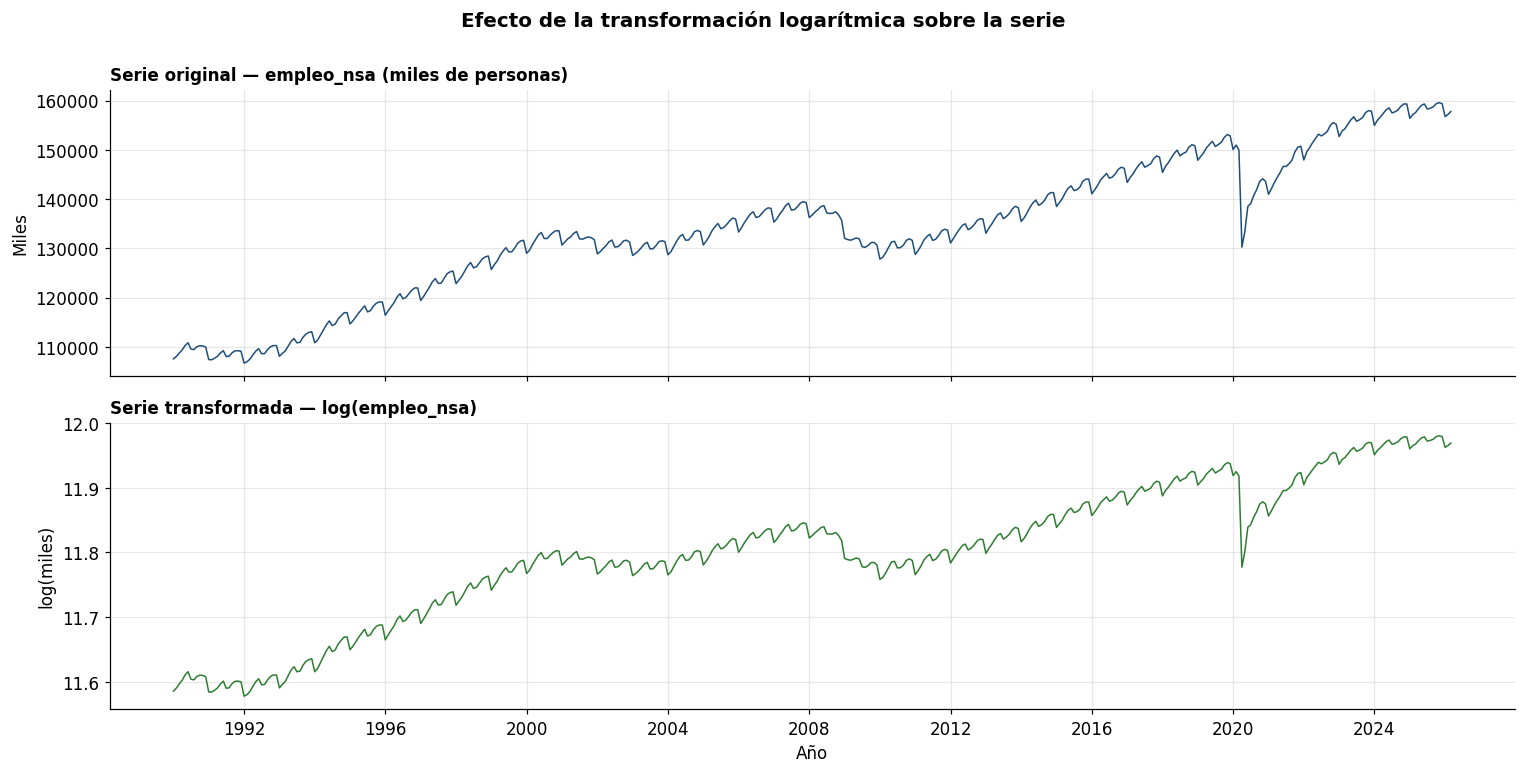


EFECTO DE LA TRANSFORMACIÓN LOG SOBRE LA VARIANZA

Década           Std (original)       Std (log)
--------------------------------------------------
1990-1999                 7,378          0.0626
2000-2009                 2,967          0.0221
2010-2019                 7,063          0.0503
2020-2026                 6,753          0.0456

✅ Series preparadas:
   - 'serie'        → serie completa (1939-2026), 1047 obs
   - 'serie_modelo' → ventana de modelado (1990-2026), 435 obs
   - 'serie_log'    → versión logarítmica de serie_modelo, 435 obs


In [8]:
# ============================================================
# Celda 3.2 — Selección, recorte y transformaciones
# ============================================================
import numpy as np

# ---- 1. Selección de variable de interés ----
serie = df["empleo_nsa"].copy()
serie.name = "empleo_nsa"
print(f"Variable seleccionada: {serie.name}")
print(f"Observaciones totales: {len(serie)}")

# ---- 2. Recorte a ventana de régimen homogéneo (1990 en adelante) ----
serie_modelo = serie.loc["1990-01-01":].copy()
print(f"\nVentana de modelado: {serie_modelo.index.min().date()} → {serie_modelo.index.max().date()}")
print(f"Observaciones en ventana: {len(serie_modelo)} ({len(serie_modelo) // 12} años)")

# ---- 3. Transformación logarítmica para estabilizar varianza ----
serie_log = np.log(serie_modelo)
serie_log.name = "log_empleo_nsa"

# ---- 4. Visualización comparativa: original vs log ----
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(serie_modelo.index, serie_modelo.values, color="#1f4e79", linewidth=1)
axes[0].set_title("Serie original — empleo_nsa (miles de personas)",
                  fontsize=11, fontweight="bold", loc="left")
axes[0].set_ylabel("Miles")

axes[1].plot(serie_log.index, serie_log.values, color="#2e7d32", linewidth=1)
axes[1].set_title("Serie transformada — log(empleo_nsa)",
                  fontsize=11, fontweight="bold", loc="left")
axes[1].set_ylabel("log(miles)")
axes[1].set_xlabel("Año")

plt.suptitle("Efecto de la transformación logarítmica sobre la serie",
             fontsize=13, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

# ---- 5. Comparación cuantitativa de varianza por subperiodo ----
print("\n" + "=" * 70)
print("EFECTO DE LA TRANSFORMACIÓN LOG SOBRE LA VARIANZA")
print("=" * 70)

bloques = [
    ("1990-1999", "1990-01-01", "1999-12-01"),
    ("2000-2009", "2000-01-01", "2009-12-01"),
    ("2010-2019", "2010-01-01", "2019-12-01"),
    ("2020-2026", "2020-01-01", "2026-03-01"),
]

print(f"\n{'Década':<12} {'Std (original)':>18} {'Std (log)':>15}")
print("-" * 50)
for nombre, ini, fin in bloques:
    std_orig = serie_modelo.loc[ini:fin].std()
    std_log = serie_log.loc[ini:fin].std()
    print(f"{nombre:<12} {std_orig:>18,.0f} {std_log:>15.4f}")

# ---- 6. Guardar series clave para uso posterior ----
print("\n✅ Series preparadas:")
print(f"   - 'serie'        → serie completa (1939-2026), {len(serie)} obs")
print(f"   - 'serie_modelo' → ventana de modelado (1990-2026), {len(serie_modelo)} obs")
print(f"   - 'serie_log'    → versión logarítmica de serie_modelo, {len(serie_log)} obs")

**Decisiones de preprocesamiento adoptadas:**

**1. Integridad del dataset.** La validación confirma que la base de datos no requiere imputación: los 1.047 meses esperados coinciden exactamente con los presentes, no hay valores faltantes en ninguna de las dos series, no hay duplicados, el índice es monotónico creciente, y los valores son estrictamente positivos (mínimo 29.296, máximo 159.571 mil empleos). Los tipos de datos son adecuados: `DatetimeIndex` con frecuencia inferida `MS` (*month start*) y valores numéricos `int64`. En consecuencia, **no se aplican operaciones de limpieza de datos faltantes**.

**2. Selección de la variable de interés.** Se selecciona `empleo_nsa` (PAYNSA) como serie objetivo del modelado. La razón, ya argumentada en el Hito 2.2, es que se busca modelar explícitamente el componente estacional, lo cual requiere que la serie no haya sido previamente desestacionalizada por el BLS.

**3. Recorte temporal a 1990–2026.** Aunque la serie completa abarca desde 1939 (1.047 observaciones), se acota la ventana de modelado a partir de **1990** por las siguientes razones:

- *Homogeneidad de régimen económico:* el coeficiente de variación cae del 14-15% en las primeras décadas a un rango más estable del 4-5% a partir del año 2000, evidencia de que la economía estadounidense post-1990 tiene una estructura estadísticamente más homogénea.
- *Estabilidad metodológica del BLS:* las clasificaciones industriales (NAICS) y los procedimientos de muestreo del CES son consistentes a partir de los años 90.
- *Volumen suficiente para SARIMA:* la ventana resultante contiene **435 observaciones (36 años × 12 meses + 3)**, ampliamente suficientes para estimar un modelo SARIMA con todos los grados de libertad necesarios para parámetros regulares y estacionales.

**4. Transformación logarítmica.** Se aplica `log(empleo_nsa)` para estabilizar la varianza. La tabla comparativa muestra el efecto de la transformación por décadas:

| Década | Std (original) | Std (log) |
|---|---|---|
| 1990–1999 | 7.378 | 0,0626 |
| 2000–2009 | 2.967 | 0,0221 |
| 2010–2019 | 7.063 | 0,0503 |
| 2020–2026 | 6.753 | 0,0456 |

Aunque la desviación estándar original no muestra una tendencia monotónica creciente (de hecho, la década 2000–2009 destaca por su baja volatilidad relativa, asociada al periodo conocido como *Great Moderation*), las magnitudes absolutas oscilan entre ~3.000 y ~7.400 mil empleos. La versión logarítmica reduce estas oscilaciones a un rango mucho más comparable (entre 0,022 y 0,063), lo que permite que el modelo SARIMA opere sobre una serie con propiedades de varianza más uniformes. Esto sugiere un comportamiento aproximadamente **multiplicativo** de la serie (la magnitud de las fluctuaciones es proporcional al nivel), por lo que la transformación log es metodológicamente apropiada.

Las **diferenciaciones regular y estacional** (pasos requeridos por SARIMA para alcanzar estacionariedad) se aplican y justifican formalmente al inicio del Hito 4, junto con las pruebas estadísticas correspondientes (ADF, KPSS).

## 4. Modelado y predicción

### 4.1 Pruebas formales de estacionariedad

Un modelo SARIMA(p, d, q)(P, D, Q)ₛ requiere que la serie, después de aplicar `d` diferencias regulares y `D` diferencias estacionales, sea **estacionaria** (media y varianza constantes en el tiempo).

Se aplican dos pruebas complementarias:

- **Test de Dickey-Fuller Aumentado (ADF).** Hipótesis nula: la serie tiene raíz unitaria (no estacionaria). Si el p-valor es menor a 0,05, se rechaza H₀ y se concluye que la serie es estacionaria.
- **Test KPSS.** Hipótesis nula: la serie es estacionaria en torno a una tendencia determinística. Si el p-valor es menor a 0,05, se rechaza H₀ y se concluye que la serie *no* es estacionaria.

Ambas pruebas tienen hipótesis nulas opuestas, por lo que su uso combinado proporciona evidencia más robusta. Se aplican sobre tres versiones de la serie:

1. Serie logarítmica original.
2. Serie logarítmica con primera diferencia regular (`d=1`).
3. Serie logarítmica con primera diferencia regular y primera diferencia estacional de orden 12 (`d=1, D=1, s=12`).

PRUEBAS DE ESTACIONARIEDAD

──────────────────────────────────────────────────────────────────────
Serie: log(empleo_nsa) — sin diferenciar
──────────────────────────────────────────────────────────────────────
  ADF  → estadístico:  -1.3528   p-valor: 0.6047   → No estacionaria
  KPSS → estadístico:   3.0137   p-valor: 0.0100   → No estacionaria
  Conclusión: ❌ NO ESTACIONARIA (ambas pruebas coinciden)

──────────────────────────────────────────────────────────────────────
Serie: log(empleo_nsa) — diferencia regular (d=1)
──────────────────────────────────────────────────────────────────────
  ADF  → estadístico:  -5.0024   p-valor: 0.0000   → Estacionaria
  KPSS → estadístico:   0.0894   p-valor: 0.1000   → Estacionaria
  Conclusión: ✅ ESTACIONARIA (ambas pruebas coinciden)

──────────────────────────────────────────────────────────────────────
Serie: log(empleo_nsa) — d=1, D=1, s=12
──────────────────────────────────────────────────────────────────────
  ADF  → estadístico:  -8.4121

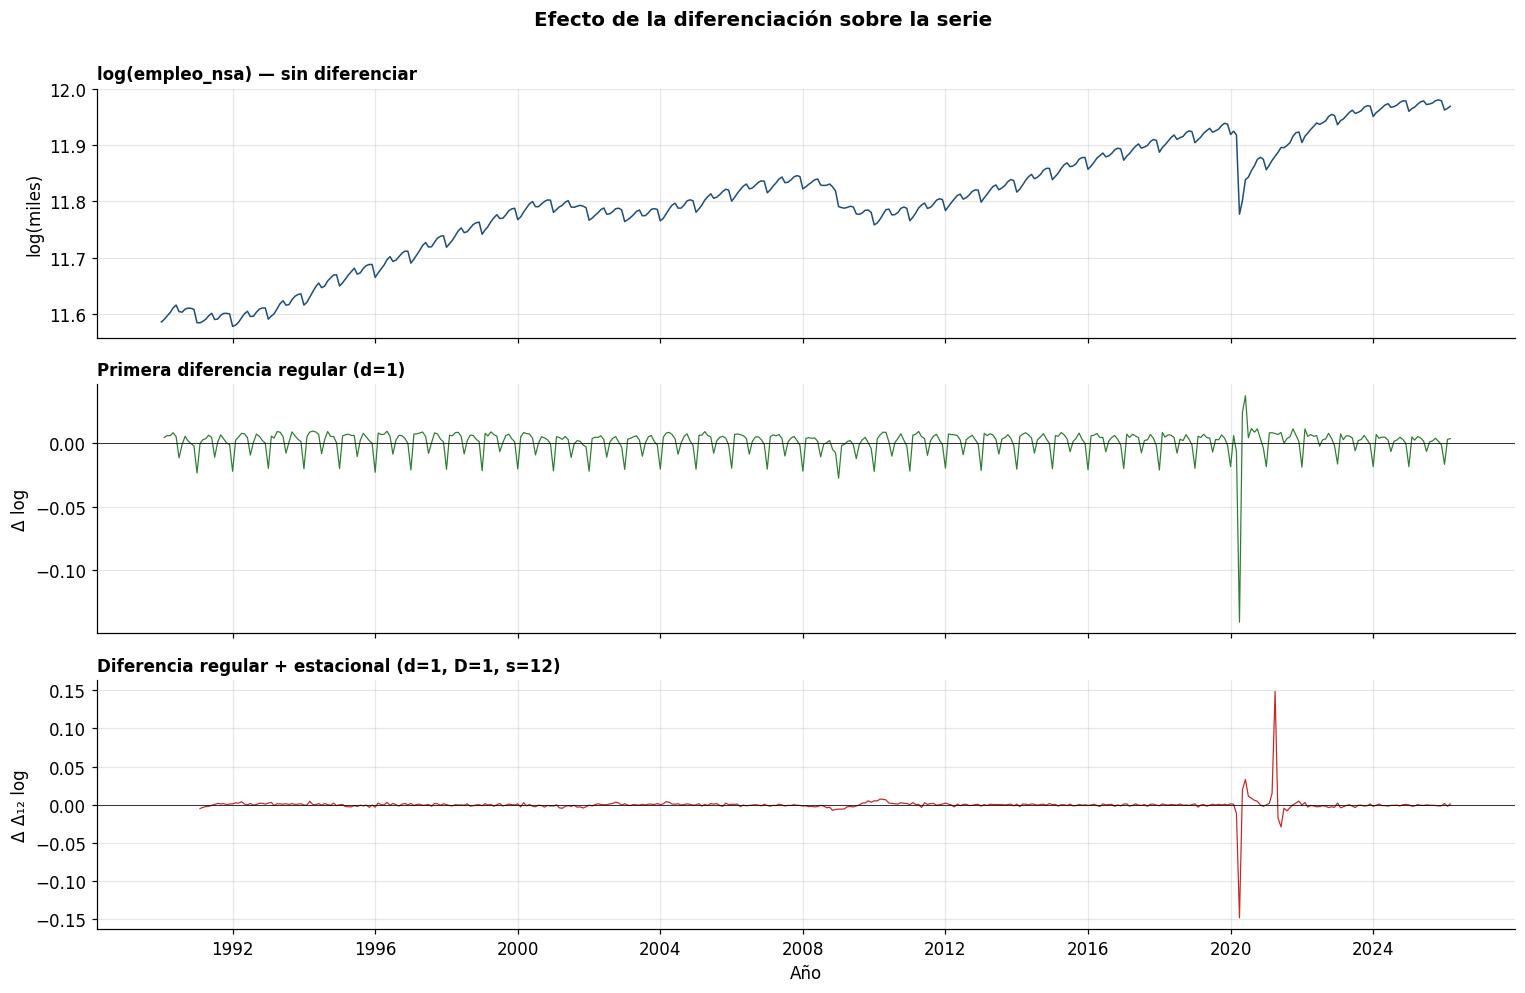


✅ Serie estacionaria preparada para análisis ACF/PACF: serie_d1_D1


In [10]:
# ============================================================
# Celda 4.1 — Pruebas de estacionariedad (ADF y KPSS)
# ============================================================
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings("ignore")  # KPSS lanza warnings inocuos para series largas

def test_estacionariedad(serie, nombre):
    """Aplica ADF y KPSS y devuelve resumen interpretado."""
    serie_clean = serie.dropna()

    # ADF
    adf_stat, adf_p, adf_lags, adf_n, adf_crit, _ = adfuller(serie_clean, autolag="AIC")
    adf_resultado = "Estacionaria" if adf_p < 0.05 else "No estacionaria"

    # KPSS
    kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(serie_clean, regression="c", nlags="auto")
    kpss_resultado = "No estacionaria" if kpss_p < 0.05 else "Estacionaria"

    # Conclusión combinada
    if adf_resultado == "Estacionaria" and kpss_resultado == "Estacionaria":
        conclusion = "✅ ESTACIONARIA (ambas pruebas coinciden)"
    elif adf_resultado == "No estacionaria" and kpss_resultado == "No estacionaria":
        conclusion = "❌ NO ESTACIONARIA (ambas pruebas coinciden)"
    else:
        conclusion = "⚠️ AMBIGUO (las pruebas discrepan)"

    print(f"\n{'─' * 70}")
    print(f"Serie: {nombre}")
    print(f"{'─' * 70}")
    print(f"  ADF  → estadístico: {adf_stat:>8.4f}   p-valor: {adf_p:.4f}   → {adf_resultado}")
    print(f"  KPSS → estadístico: {kpss_stat:>8.4f}   p-valor: {kpss_p:.4f}   → {kpss_resultado}")
    print(f"  Conclusión: {conclusion}")

    return {"adf_p": adf_p, "kpss_p": kpss_p, "conclusion": conclusion}

# ---- Aplicar a las tres versiones de la serie ----
print("=" * 70)
print("PRUEBAS DE ESTACIONARIEDAD")
print("=" * 70)

# Versión 1: serie logarítmica original
r1 = test_estacionariedad(serie_log, "log(empleo_nsa) — sin diferenciar")

# Versión 2: primera diferencia regular
serie_d1 = serie_log.diff()
r2 = test_estacionariedad(serie_d1, "log(empleo_nsa) — diferencia regular (d=1)")

# Versión 3: diferencia regular + diferencia estacional
serie_d1_D1 = serie_log.diff().diff(12)
r3 = test_estacionariedad(serie_d1_D1, "log(empleo_nsa) — d=1, D=1, s=12")

# ---- Visualización de las tres versiones ----
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(serie_log.index, serie_log.values, color="#1f4e79", linewidth=1)
axes[0].set_title("log(empleo_nsa) — sin diferenciar", fontsize=11, fontweight="bold", loc="left")
axes[0].set_ylabel("log(miles)")

axes[1].plot(serie_d1.index, serie_d1.values, color="#2e7d32", linewidth=0.8)
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_title("Primera diferencia regular (d=1)", fontsize=11, fontweight="bold", loc="left")
axes[1].set_ylabel("Δ log")

axes[2].plot(serie_d1_D1.index, serie_d1_D1.values, color="#c62828", linewidth=0.8)
axes[2].axhline(0, color="black", linewidth=0.5)
axes[2].set_title("Diferencia regular + estacional (d=1, D=1, s=12)",
                  fontsize=11, fontweight="bold", loc="left")
axes[2].set_ylabel("Δ Δ₁₂ log")
axes[2].set_xlabel("Año")

plt.suptitle("Efecto de la diferenciación sobre la serie", fontsize=13, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

# Guardar la serie diferenciada para Paso 4.2
print("\n✅ Serie estacionaria preparada para análisis ACF/PACF: serie_d1_D1")

**Resultados de las pruebas de estacionariedad:**

| Serie | ADF (estadístico / p-valor) | KPSS (estadístico / p-valor) | Conclusión |
|---|---|---|---|
| log(empleo_nsa) — sin diferenciar | −1,3528 / 0,6047 | 3,0137 / 0,0100 | **No estacionaria** |
| log(empleo_nsa) — d=1 | −5,0024 / 0,0000 | 0,0894 / 0,1000 | Estacionaria |
| log(empleo_nsa) — d=1, D=1, s=12 | −8,4121 / 0,0000 | 0,0187 / 0,1000 | **Estacionaria (más robusta)** |

**Interpretación:**

**Serie sin diferenciar.** Ambas pruebas coinciden contundentemente en que la serie logarítmica original **no es estacionaria**: el test ADF no rechaza la hipótesis nula de raíz unitaria (p = 0,6047 ≫ 0,05) y el test KPSS rechaza la hipótesis nula de estacionariedad (p = 0,0100 < 0,05). Este resultado era esperable a partir del análisis exploratorio, dado que la serie presenta una tendencia secular creciente clara.

**Primera diferencia regular (d=1).** La aplicación de una sola diferencia regular es suficiente para que ambas pruebas coincidan en estacionariedad: el ADF rechaza H₀ con p < 0,0001 (estadístico = −5,00, muy por debajo de los valores críticos) y el KPSS no rechaza H₀ (p = 0,1000). Esto indica que la serie tiene **un orden de integración igual a 1** (es I(1)) en su componente regular.

**Diferencia regular + estacional (d=1, D=1, s=12).** Aunque la diferenciación regular ya logra estacionariedad estadística, la aplicación adicional de una diferencia estacional refuerza el resultado: el estadístico ADF mejora de −5,00 a **−8,41** (más alejado del cero, mayor evidencia contra la raíz unitaria) y el KPSS pasa de 0,089 a **0,019** (más cercano a cero, mayor evidencia de estacionariedad).

**Decisión metodológica sobre D.** Las pruebas ADF y KPSS no están diseñadas para detectar específicamente *raíces unitarias estacionales*; evalúan la estacionariedad global pero pueden pasar por alto un patrón cíclico que se mantiene en la serie diferenciada regularmente. Existen pruebas específicas para esto (como OCSB y CH), pero la decisión más sólida en este caso se sustenta en tres argumentos convergentes:

1. La descomposición STL del Hito 2.3 evidenció una **amplitud estacional de 4.223 mil empleos** (3,15% de la media), un componente no despreciable.
2. El análisis exploratorio del Hito 2.4 cuantificó una **brecha estacional sistemática de 4.323 mil empleos** entre noviembre y enero, con un patrón consistente a lo largo de tres décadas.
3. La diferenciación estacional adicional **mejora ambos estadísticos** (ADF y KPSS), lo cual es coherente con que la serie efectivamente posee una raíz estacional.

En consecuencia, el modelo se especifica con **`d = 1` y `D = 1`** (orden de integración regular y estacional iguales a uno), con periodo estacional **`s = 12`** (mensual). La determinación de los órdenes autoregresivos y de media móvil (`p, q, P, Q`) se realiza en el paso siguiente mediante análisis de las funciones de autocorrelación.

### 4.2 Análisis de autocorrelación: identificación de órdenes (p, q, P, Q)

Establecidos los órdenes de diferenciación (d=1, D=1, s=12) en el paso anterior, se procede a identificar los órdenes autoregresivo (p, P) y de media móvil (q, Q) mediante las funciones de **autocorrelación (ACF)** y **autocorrelación parcial (PACF)** de la serie ya estacionaria.

La metodología clásica de Box-Jenkins establece:
- **PACF** orienta sobre los órdenes **AR (p, P)**: se observa en qué rezago se "corta" abruptamente.
- **ACF** orienta sobre los órdenes **MA (q, Q)**: se observa en qué rezago se "corta" abruptamente.
- **Rezagos no estacionales** (1, 2, 3, ...) sugieren los órdenes regulares (p, q).
- **Rezagos estacionales** (12, 24, 36) sugieren los órdenes estacionales (P, Q).

Cualquier barra que sobresalga de las bandas de confianza (sombreadas en azul claro) representa una autocorrelación estadísticamente significativa al 5%.

Serie estacionaria — observaciones: 422
Rango: 1991-02-01 → 2026-03-01


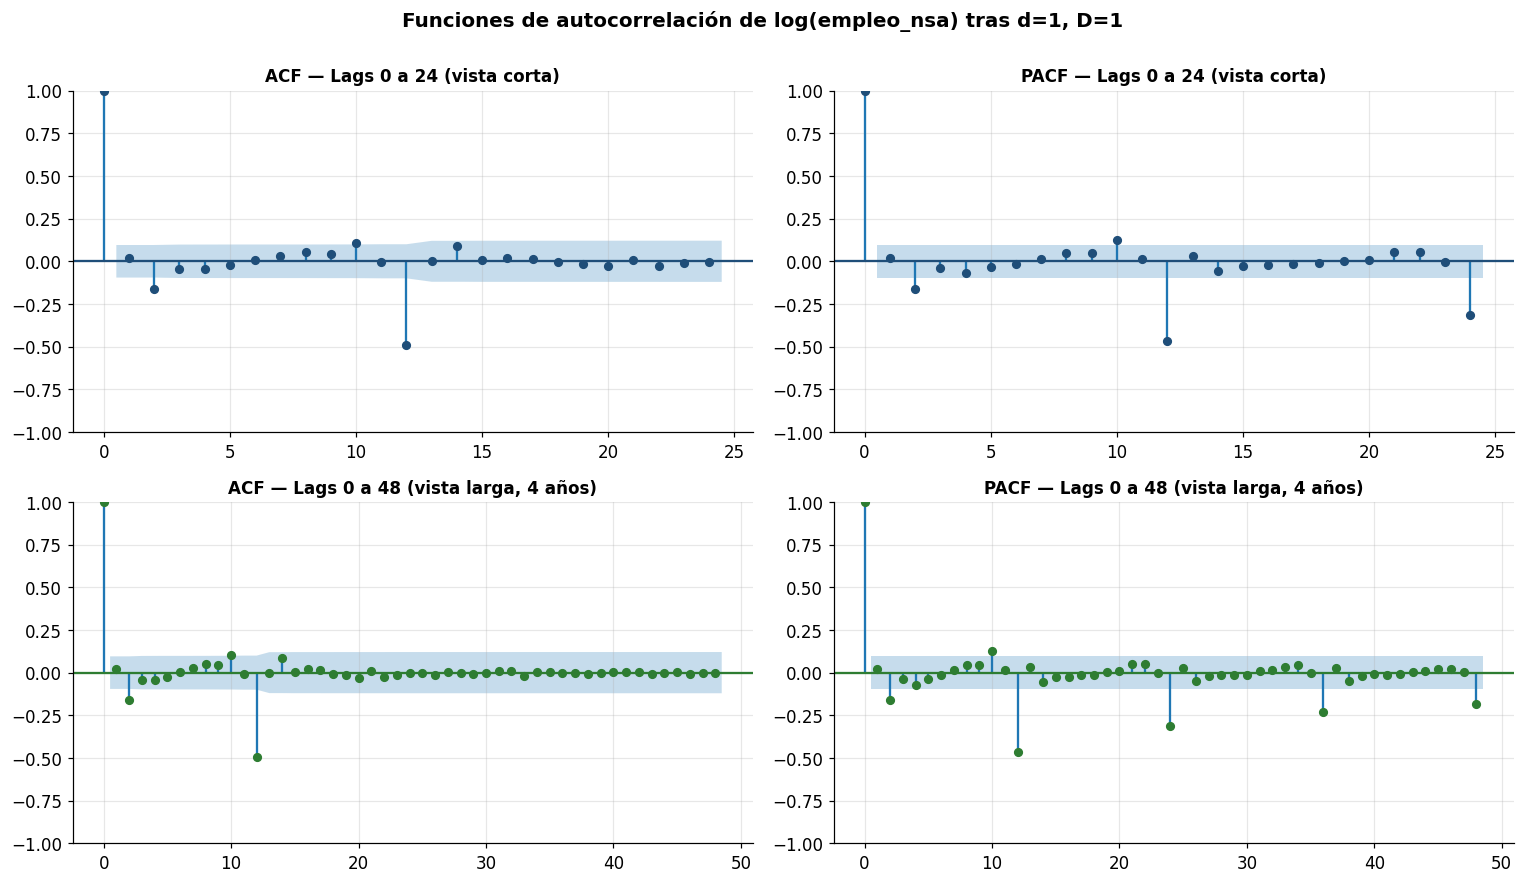


VALORES NUMÉRICOS DE LOS REZAGOS CLAVE

  Lag        ACF       PACF    Comentario                    
-----------------------------------------------------------------
    1     0.0216     0.0216    ← Lag regular
    2    -0.1618    -0.1623    ← Lag regular
    3    -0.0437    -0.0371    ← Lag regular
    6     0.0049    -0.0153    
   11    -0.0060     0.0150    
   12    -0.4928    -0.4673    ← Lag estacional
   13    -0.0009     0.0326    
   23    -0.0115    -0.0019    
   24    -0.0016    -0.3129    ← Lag estacional
   25    -0.0008     0.0278    
   35     0.0061    -0.0014    
   36    -0.0022    -0.2288    ← Lag estacional

Banda de confianza al 95%: ± 0.0954
(Valores fuera de esta banda son estadísticamente significativos)


In [11]:
# ============================================================
# Celda 4.2 — ACF y PACF de la serie diferenciada
# ============================================================
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Limpiar NaN producidos por las diferenciaciones
serie_estacionaria = serie_d1_D1.dropna()

print(f"Serie estacionaria — observaciones: {len(serie_estacionaria)}")
print(f"Rango: {serie_estacionaria.index.min().date()} → {serie_estacionaria.index.max().date()}")

# ---- ACF y PACF con dos niveles de zoom ----
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Vista corta (lags 0-24): para órdenes regulares y primer rezago estacional
plot_acf(serie_estacionaria, lags=24, ax=axes[0, 0], color="#1f4e79")
axes[0, 0].set_title("ACF — Lags 0 a 24 (vista corta)", fontsize=11, fontweight="bold")

plot_pacf(serie_estacionaria, lags=24, ax=axes[0, 1], color="#1f4e79", method="ywm")
axes[0, 1].set_title("PACF — Lags 0 a 24 (vista corta)", fontsize=11, fontweight="bold")

# Vista larga (lags 0-48): para órdenes estacionales múltiples
plot_acf(serie_estacionaria, lags=48, ax=axes[1, 0], color="#2e7d32")
axes[1, 0].set_title("ACF — Lags 0 a 48 (vista larga, 4 años)", fontsize=11, fontweight="bold")

plot_pacf(serie_estacionaria, lags=48, ax=axes[1, 1], color="#2e7d32", method="ywm")
axes[1, 1].set_title("PACF — Lags 0 a 48 (vista larga, 4 años)", fontsize=11, fontweight="bold")

plt.suptitle("Funciones de autocorrelación de log(empleo_nsa) tras d=1, D=1",
             fontsize=13, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

# ---- Imprimir valores numéricos de los lags clave ----
from statsmodels.tsa.stattools import acf, pacf

acf_vals = acf(serie_estacionaria, nlags=36, fft=True)
pacf_vals = pacf(serie_estacionaria, nlags=36, method="ywm")

print("\n" + "=" * 70)
print("VALORES NUMÉRICOS DE LOS REZAGOS CLAVE")
print("=" * 70)
print(f"\n{'Lag':>5} {'ACF':>10} {'PACF':>10}    {'Comentario':<30}")
print("-" * 65)

lags_clave = [1, 2, 3, 6, 11, 12, 13, 23, 24, 25, 35, 36]
for lag in lags_clave:
    acf_v = acf_vals[lag]
    pacf_v = pacf_vals[lag]
    if lag in [12, 24, 36]:
        comentario = "← Lag estacional"
    elif lag in [1, 2, 3]:
        comentario = "← Lag regular"
    else:
        comentario = ""
    print(f"{lag:>5} {acf_v:>10.4f} {pacf_v:>10.4f}    {comentario}")

# Banda de confianza al 95%
n = len(serie_estacionaria)
banda = 1.96 / np.sqrt(n)
print(f"\nBanda de confianza al 95%: ± {banda:.4f}")
print(f"(Valores fuera de esta banda son estadísticamente significativos)")

**Resultados del análisis ACF/PACF:**

La serie diferenciada (d=1, D=1, s=12) cuenta con **422 observaciones** efectivas tras la pérdida por diferenciación. La banda de confianza al 95% es **± 0,0954**; cualquier autocorrelación fuera de este intervalo se considera estadísticamente significativa.

**Valores numéricos en los rezagos clave:**

| Lag | ACF | PACF | Significativo (>±0,0954) | Naturaleza |
|---|---|---|---|---|
| 1 | 0,0216 | 0,0216 | No | Regular |
| 2 | −0,1618 | −0,1623 | Sí (ambos) | Regular |
| 3 | −0,0437 | −0,0371 | No | Regular |
| 11 | −0,0060 | 0,0150 | No | Regular |
| **12** | **−0,4928** | **−0,4673** | **Sí (ambos, fuertemente)** | **Estacional** |
| 13 | −0,0009 | 0,0326 | No | Regular |
| 24 | −0,0016 | **−0,3129** | Sí (solo PACF) | Estacional |
| 36 | −0,0022 | **−0,2288** | Sí (solo PACF) | Estacional |

**Interpretación de la parte estacional.** El patrón observado en los rezagos estacionales es **inequívoco y didácticamente claro**: la ACF presenta un pico negativo masivo en el lag 12 (−0,4928) y se vuelve esencialmente nula en lags 24 (−0,0016) y 36 (−0,0022). En contraste, la PACF presenta valores significativos en lags 12, 24 y 36 que decaen gradualmente (−0,4673 → −0,3129 → −0,2288). Esta combinación —ACF que se corta abruptamente en el lag estacional, PACF que decae gradualmente en múltiplos del periodo estacional— es la firma característica de un proceso de **media móvil estacional de orden 1**: **Q = 1**. Si fuera un proceso AR estacional, el patrón sería el contrario.

**Interpretación de la parte regular.** En los rezagos no estacionales, el comportamiento es más débil. El lag 1 es prácticamente nulo en ambas funciones (0,0216), y solo el lag 2 supera marginalmente la banda de confianza (−0,1618 en ACF, −0,1623 en PACF). Esto sugiere que la dinámica regular de la serie es de baja magnitud una vez removida la estacionalidad. Las opciones razonables son:

- `(p=0, q=0)` — modelo regular sin componente, dejando que las diferenciaciones expliquen la dinámica regular.
- `(p=0, q=1)` — modelo MA(1) regular para capturar el lag 2 vía un solo parámetro.
- `(p=1, q=1)` — modelo más flexible, a evaluar po

### 4.3 División train/test, ajuste y selección del modelo

**Ventana de pronóstico.** Se selecciona un horizonte de **24 meses (2 años)**. Esta elección se sustenta en tres argumentos:

1. *Cobertura de dos ciclos estacionales completos*, lo que permite evaluar si el modelo captura adecuadamente el patrón mensual repetitivo identificado en los hitos previos.
2. *Convención académica*: el horizonte de 12–24 meses es estándar en la literatura de pronóstico macroeconómico (Hyndman & Athanasopoulos, 2021).
3. *Interpretabilidad*: a 2 años el pronóstico mantiene utilidad práctica, mientras que horizontes mayores tienden a degradarse rápidamente en series con shocks estructurales.

**División del conjunto de datos.** El entrenamiento se realiza con datos hasta marzo de 2024, dejando los **24 meses más recientes (abril 2024 – marzo 2026)** como conjunto de prueba para evaluación fuera de muestra. El conjunto de entrenamiento incluye deliberadamente el shock COVID-19 (2020–2021), reproduciendo la situación realista de un analista que ajusta el modelo con la totalidad de los datos disponibles. La capacidad del modelo para "absorber" este shock atípico se evalúa críticamente en el Hito 5.

**Estrategia de selección.** Se ajustan los tres modelos candidatos identificados en el Paso 4.2 y se compara su desempeño mediante:

- **AIC (Akaike Information Criterion):** premia el ajuste, penaliza la complejidad.
- **BIC (Bayesian Information Criterion):** penaliza la complejidad de forma más estricta que AIC; preferido cuando se busca parsimonia.
- **Log-verosimilitud:** mayor valor indica mejor ajuste a los datos de entrenamiento.

El modelo seleccionado se utilizará en los pasos 4.4 (diagnóstico de residuos) y 4.5 (pronóstico).

In [14]:
# ============================================================
# Celda 4.3 — División train/test y ajuste de modelos candidatos
# ============================================================
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ---- 1. División train/test ----
H = 24  # horizonte de pronóstico en meses

train = serie_log.iloc[:-H]
test  = serie_log.iloc[-H:]

print("=" * 70)
print("DIVISIÓN TRAIN/TEST")
print("=" * 70)
print(f"Train: {train.index.min().date()} -> {train.index.max().date()}  "
      f"({len(train)} obs, {len(train) / 12:.1f} anios)")
print(f"Test:  {test.index.min().date()}  -> {test.index.max().date()}   "
      f"({len(test)} obs, {len(test) / 12:.1f} anios)")

# Equivalentes en escala original (para referencia)
train_orig = serie_modelo.iloc[:-H]
test_orig  = serie_modelo.iloc[-H:]

# ---- 2. Ajuste de los tres candidatos ----
print("\n" + "=" * 70)
print("AJUSTE DE MODELOS CANDIDATOS")
print("=" * 70)

candidatos = {
    "M1 - SARIMA(0,1,1)(0,1,1)[12] airline": dict(order=(0,1,1), seasonal_order=(0,1,1,12)),
    "M2 - SARIMA(1,1,1)(0,1,1)[12]":          dict(order=(1,1,1), seasonal_order=(0,1,1,12)),
    "M3 - SARIMA(0,1,2)(0,1,1)[12]":          dict(order=(0,1,2), seasonal_order=(0,1,1,12)),
}

resultados = {}
for nombre, params in candidatos.items():
    try:
        modelo = SARIMAX(
            train,
            order=params["order"],
            seasonal_order=params["seasonal_order"],
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        fit = modelo.fit(disp=False)
        resultados[nombre] = fit
        print(f"\n{nombre}")
        print(f"   AIC: {fit.aic:>10.2f}   BIC: {fit.bic:>10.2f}   "
              f"LogLik: {fit.llf:>10.2f}")
    except Exception as e:
        print(f"\n{nombre}\n   ERROR: {e}")

# ---- 3. Tabla comparativa ----
print("\n" + "=" * 70)
print("COMPARACION DE MODELOS")
print("=" * 70)

tabla_comp = pd.DataFrame({
    "AIC":      [r.aic for r in resultados.values()],
    "BIC":      [r.bic for r in resultados.values()],
    "LogLik":   [r.llf for r in resultados.values()],
    "n_params": [len(r.params) for r in resultados.values()],
}, index=resultados.keys())

tabla_comp["AIC"]    = tabla_comp["AIC"].round(2)
tabla_comp["BIC"]    = tabla_comp["BIC"].round(2)
tabla_comp["LogLik"] = tabla_comp["LogLik"].round(2)

print("\n" + tabla_comp.to_string())

mejor_aic = tabla_comp["AIC"].idxmin()
mejor_bic = tabla_comp["BIC"].idxmin()

print(f"\nMejor por AIC: {mejor_aic}")
print(f"Mejor por BIC: {mejor_bic}")

# ---- 4. Resumen del modelo seleccionado por BIC ----
modelo_final = resultados[mejor_bic]
nombre_final = mejor_bic

print("\n" + "=" * 70)
print(f"MODELO SELECCIONADO: {nombre_final}")
print("=" * 70)
print(modelo_final.summary())

DIVISIÓN TRAIN/TEST
Train: 1990-01-01 -> 2024-03-01  (411 obs, 34.2 anios)
Test:  2024-04-01  -> 2026-03-01   (24 obs, 2.0 anios)

AJUSTE DE MODELOS CANDIDATOS

M1 - SARIMA(0,1,1)(0,1,1)[12] airline
   AIC:   -2584.96   BIC:   -2573.11   LogLik:    1295.48

M2 - SARIMA(1,1,1)(0,1,1)[12]
   AIC:   -2582.18   BIC:   -2566.38   LogLik:    1295.09

M3 - SARIMA(0,1,2)(0,1,1)[12]
   AIC:   -2584.29   BIC:   -2568.50   LogLik:    1296.14

COMPARACION DE MODELOS

                                           AIC      BIC   LogLik  n_params
M1 - SARIMA(0,1,1)(0,1,1)[12] airline -2584.96 -2573.11  1295.48         3
M2 - SARIMA(1,1,1)(0,1,1)[12]         -2582.18 -2566.38  1295.09         4
M3 - SARIMA(0,1,2)(0,1,1)[12]         -2584.29 -2568.50  1296.14         4

Mejor por AIC: M1 - SARIMA(0,1,1)(0,1,1)[12] airline
Mejor por BIC: M1 - SARIMA(0,1,1)(0,1,1)[12] airline

MODELO SELECCIONADO: M1 - SARIMA(0,1,1)(0,1,1)[12] airline
                                     SARIMAX Results                     

**Resultados de la comparación de modelos:**

| Modelo | AIC | BIC | LogLik | n_params |
|---|---|---|---|---|
| **M1 — SARIMA(0,1,1)(0,1,1)₁₂ airline** | **−2.584,96** | **−2.573,11** | 1.295,48 | 3 |
| M2 — SARIMA(1,1,1)(0,1,1)₁₂ | −2.582,18 | −2.566,38 | 1.295,09 | 4 |
| M3 — SARIMA(0,1,2)(0,1,1)₁₂ | −2.584,29 | −2.568,50 | 1.296,14 | 4 |

**Selección.** El modelo **M1 (airline)** resulta seleccionado por **ambos criterios de información simultáneamente** (AIC y BIC). Esta coincidencia es relevante: AIC tiende a favorecer modelos más complejos, mientras que BIC penaliza más severamente la complejidad; cuando ambos convergen al mismo modelo, la selección es robusta. Los modelos M2 y M3 ofrecen mejoras marginales en log-verosimilitud (diferencias inferiores a 1 punto) que no compensan el costo de los parámetros adicionales.

**Coeficientes del modelo seleccionado.**

| Parámetro | Coeficiente | Std. Error | z | p-valor | IC 95% |
|---|---|---|---|---|---|
| ma.L1 | 0,0608 | 0,016 | 3,809 | < 0,001 | [0,030; 0,092] |
| ma.S.L12 | −0,9189 | 0,028 | −32,452 | < 0,001 | [−0,974; −0,863] |
| sigma² | 6,6 × 10⁻⁵ | 4,64 × 10⁻⁷ | 142,243 | < 0,001 | — |

Ambos parámetros estructurales son altamente significativos (p < 0,001). Destacan dos aspectos:

1. **El parámetro de media móvil estacional (ma.S.L12 = −0,9189)** está cerca del límite teórico de invertibilidad (−1), lo que indica un patrón estacional **muy fuerte y muy estable** a lo largo del periodo de entrenamiento. Esto es coherente con los hallazgos de los Hitos 2.3 y 2.4, donde se cuantificó una brecha estacional consistente de aproximadamente 4,3 millones de empleos.

2. **El parámetro de media móvil regular (ma.L1 = 0,0608)** es positivo y de magnitud reducida, divergiendo del patrón típico del modelo airline (donde suele ser negativo). Esto refleja la baja autocorrelación regular ya observada en el análisis ACF/PACF (lag 1 = 0,022). Aunque su efecto práctico es pequeño, su inclusión es estadísticamente significativa.

**Diagnóstico preliminar de residuos.** El resumen del modelo reporta los siguientes tests:

| Test | Estadístico | p-valor | Interpretación |
|---|---|---|---|
| Ljung-Box (Q) | 0,02 | 0,89 | ✅ **No hay autocorrelación residual** |
| Jarque-Bera (JB) | 1.237.745,97 | 0,00 | ❌ Residuos no normales |
| Heterocedasticidad (H) | 65,33 | 0,00 | ❌ Varianza no constante |
| Asimetría (Skew) | −15,13 | — | ❌ Asimetría extrema negativa |
| Curtosis | 279,48 | — | ❌ Colas extremadamente pesadas |

**Lectura crítica.** Los resultados son **mixtos pero metodológicamente coherentes**:

- El test de **Ljung-Box no rechaza la hipótesis nula** (p = 0,89), lo cual indica que el modelo capturó adecuadamente la estructura de dependencia temporal de la serie. Este es el diagnóstico más importante para validar la especificación del modelo: los residuos se comportan como ruido blanco en términos de autocorrelación.

- Los tests de normalidad (Jarque-Bera) y homocedasticidad rechazan sus respectivas hipótesis nulas con magnitudes extremas. La curtosis de **279,48** y la asimetría de **−15,13** son valores altamente atípicos (la distribución normal tiene curtosis = 3 y asimetría = 0). Estos valores no responden a una mala especificación del modelo, sino al **shock de COVID-19 (abril 2020)**, que generó una caída sin precedentes de aproximadamente 22 millones de empleos en dos meses, produciendo un residuo de magnitud excepcional que domina todos los estadísticos distribucionales.

**Implicaciones.** El modelo SARIMA airline captura adecuadamente la **dinámica temporal sistemática** de la serie (tendencia + estacionalidad + autocorrelación), pero el shock COVID compromete los supuestos distribucionales sobre los cuales se construyen los intervalos de confianza paramétricos. En la práctica, esto significa que:

- Los **pronósticos puntuales** del modelo seguirán siendo razonables (la dinámica está bien capturada).
- Los **intervalos de confianza** podrán ser engañosos, especialmente respecto a la cobertura nominal del 95%.
- **Justifica metodológicamente la inclusión del modelo Prophet** (Hito 4.5), que incorpora mecanismos explícitos para manejar changepoints y eventos atípicos, ofreciendo un punto de comparación valioso.

El diagnóstico visual de los residuos se desarrolla en el Paso 4.4 para profundizar en estos hallazgos.

### 4.4 Diagnóstico visual de residuos

El paso 4.3 reveló diagnósticos distribucionales atípicos (curtosis = 279,48; asimetría = −15,13) que sugieren la presencia de outliers extremos. Esta sección verifica visualmente la naturaleza de esos residuos mediante cuatro gráficos clásicos:

1. **Serie temporal de residuos:** detección visual de outliers, cambios de varianza o tendencia residual.
2. **Histograma + curva normal teórica:** evaluación de la normalidad de la distribución.
3. **QQ-plot (normal):** evaluación de la normalidad en las colas.
4. **ACF de los residuos:** confirmación de que no queda autocorrelación sin capturar.

Adicionalmente, se realiza un análisis de robustez recalculando los estadísticos distribucionales tras excluir los residuos correspondientes al shock COVID-19 (marzo 2020 – diciembre 2020), para cuantificar empíricamente el peso del shock en los diagnósticos.

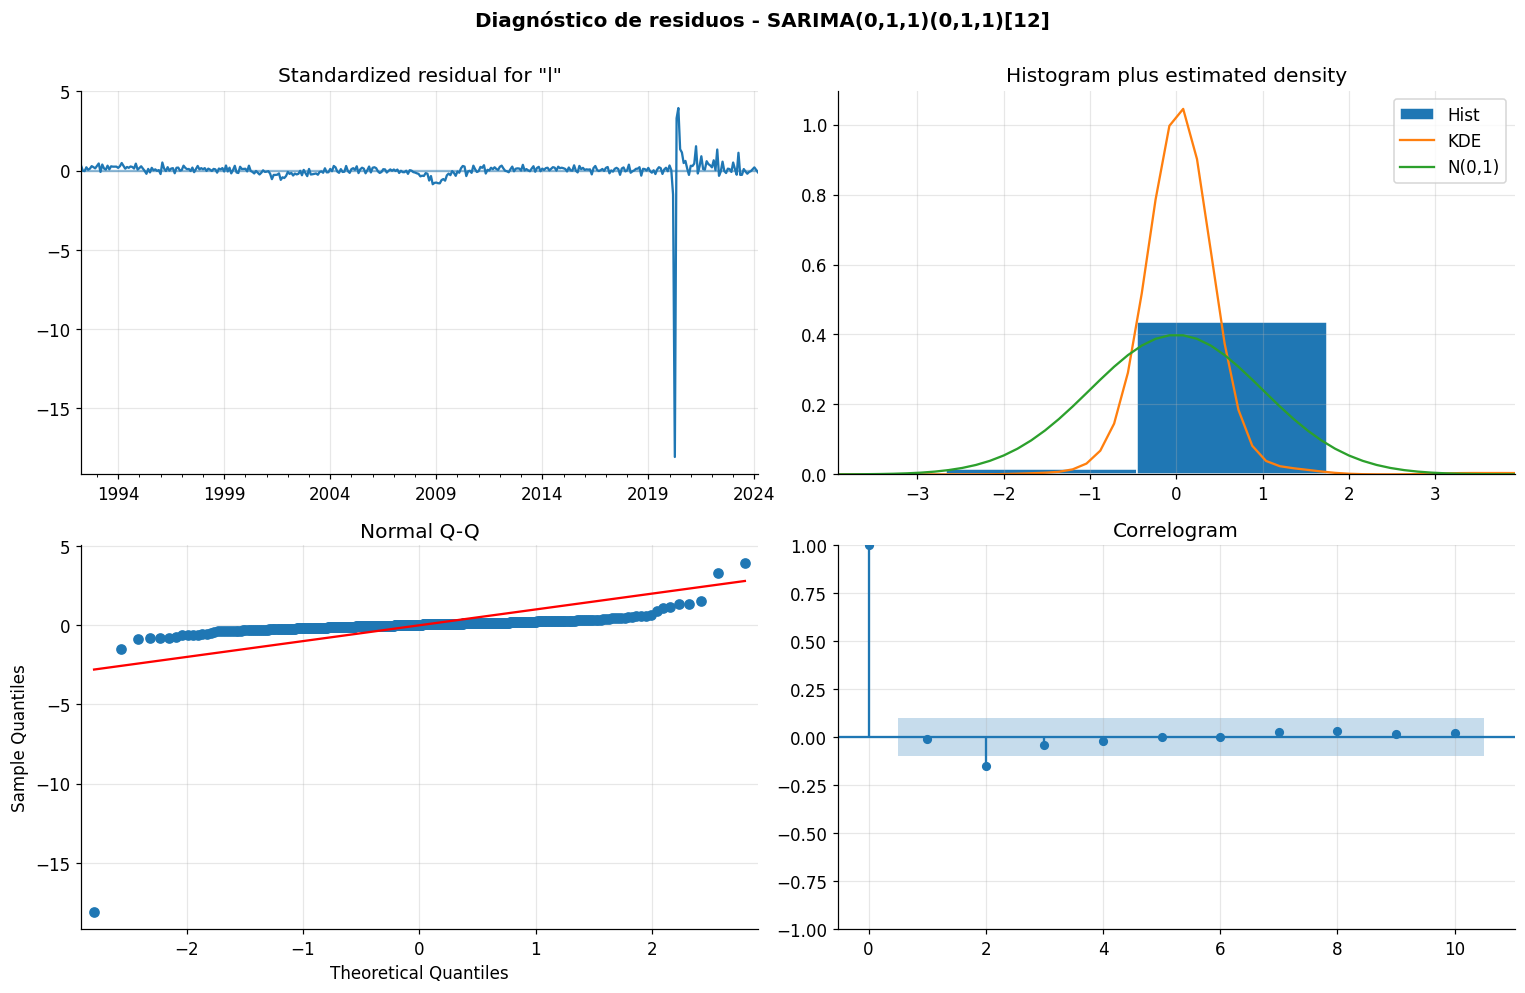

ANALISIS DE OUTLIERS EN RESIDUOS

Top 5 residuos mas extremos (valor absoluto):
--------------------------------------------------
  2020-04-01:    -0.1471   (|resid| = 0.1471)
  2020-06-01:     0.0321   (|resid| = 0.0321)
  2020-05-01:     0.0269   (|resid| = 0.0269)
  2021-04-01:     0.0125   (|resid| = 0.0125)
  2020-03-01:    -0.0123   (|resid| = 0.0123)

EFECTO DEL SHOCK COVID EN LOS DIAGNOSTICOS

                          Conjunto   N  Media    Std     Skew  Kurtosis      JB stat JB p-valor
                 Con COVID (todos) 398 0.0001 0.0080 -15.3102  284.2858 1355787.4163   0.00e+00
Sin COVID (mar-dic 2020 excluidos) 388 0.0003 0.0021   0.5256    5.6643     536.5636  3.07e-117


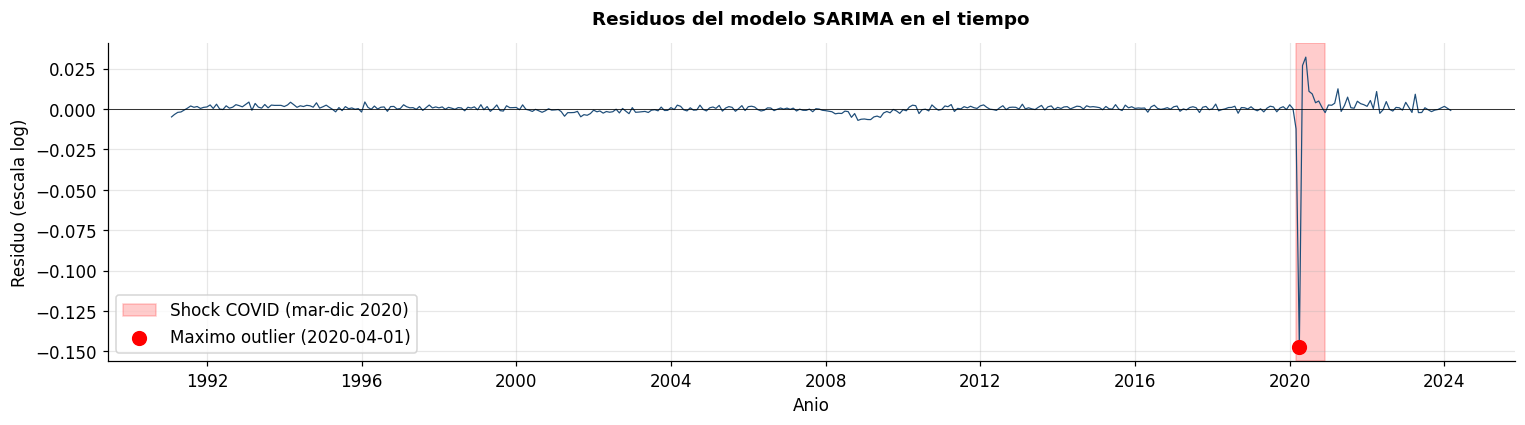


TEST DE LJUNG-BOX EN MULTIPLES LAGS

     Estadistico Q  p-valor
Lag                        
6           9.3421   0.1552
12         11.2676   0.5061
18         12.2805   0.8324
24         13.4652   0.9578
36         15.8558   0.9986

H0: los residuos no presentan autocorrelacion hasta el lag k
Si p-valor > 0.05 -> no se rechaza H0 -> residuos son ruido blanco


In [15]:
# ============================================================
# Celda 4.4 — Diagnóstico de residuos del modelo SARIMA seleccionado
# ============================================================
import scipy.stats as stats

# ---- 1. Diagnóstico estándar de statsmodels ----
fig = modelo_final.plot_diagnostics(figsize=(14, 9))
fig.suptitle("Diagnóstico de residuos - SARIMA(0,1,1)(0,1,1)[12]",
             fontsize=13, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

# ---- 2. Identificacion del outlier mas grande ----
residuos = modelo_final.resid

# Excluir los primeros 13 valores (NaN/efectos de borde por las diferenciaciones)
residuos_validos = residuos.iloc[13:]

print("=" * 70)
print("ANALISIS DE OUTLIERS EN RESIDUOS")
print("=" * 70)

# Top 5 residuos en valor absoluto
top_outliers = residuos_validos.abs().sort_values(ascending=False).head(5)
print("\nTop 5 residuos mas extremos (valor absoluto):")
print("-" * 50)
for fecha, valor_abs in top_outliers.items():
    valor_real = residuos_validos.loc[fecha]
    print(f"  {fecha.date()}: {valor_real:>10.4f}   (|resid| = {valor_abs:.4f})")

# ---- 3. Comparacion: con y sin shock COVID ----
print("\n" + "=" * 70)
print("EFECTO DEL SHOCK COVID EN LOS DIAGNOSTICOS")
print("=" * 70)

# Definir periodo COVID
inicio_covid = "2020-03-01"
fin_covid    = "2020-12-01"

residuos_con_covid = residuos_validos.copy()
residuos_sin_covid = residuos_validos.drop(
    residuos_validos.loc[inicio_covid:fin_covid].index
)

def describir(serie, nombre):
    return {
        "Conjunto": nombre,
        "N": len(serie),
        "Media": serie.mean(),
        "Std": serie.std(),
        "Skew": stats.skew(serie),
        "Kurtosis": stats.kurtosis(serie),  # exceso (normal = 0)
        "JB stat": stats.jarque_bera(serie)[0],
        "JB p-valor": stats.jarque_bera(serie)[1],
    }

comp = pd.DataFrame([
    describir(residuos_con_covid, "Con COVID (todos)"),
    describir(residuos_sin_covid, "Sin COVID (mar-dic 2020 excluidos)"),
])

# Formateo de la tabla
for col in ["Media", "Std", "Skew", "Kurtosis", "JB stat"]:
    comp[col] = comp[col].round(4)
comp["JB p-valor"] = comp["JB p-valor"].apply(lambda x: f"{x:.2e}")

print("\n" + comp.to_string(index=False))

# ---- 4. Visualizacion de residuos con marcado de COVID ----
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(residuos_validos.index, residuos_validos.values,
        color="#1f4e79", linewidth=0.8)
ax.axhline(0, color="black", linewidth=0.5)

# Sombrear periodo COVID
ax.axvspan(pd.Timestamp(inicio_covid), pd.Timestamp(fin_covid),
           alpha=0.2, color="red", label="Shock COVID (mar-dic 2020)")

# Marcar el outlier maximo
fecha_max = top_outliers.index[0]
valor_max = residuos_validos.loc[fecha_max]
ax.scatter([fecha_max], [valor_max], color="red", s=80, zorder=5,
           label=f"Maximo outlier ({fecha_max.date()})")

ax.set_title("Residuos del modelo SARIMA en el tiempo",
             fontsize=12, fontweight="bold", pad=12)
ax.set_xlabel("Anio")
ax.set_ylabel("Residuo (escala log)")
ax.legend(loc="lower left", frameon=True)

plt.tight_layout()
plt.show()

# ---- 5. Test de Ljung-Box extendido ----
from statsmodels.stats.diagnostic import acorr_ljungbox

print("\n" + "=" * 70)
print("TEST DE LJUNG-BOX EN MULTIPLES LAGS")
print("=" * 70)

lb = acorr_ljungbox(residuos_validos, lags=[6, 12, 18, 24, 36], return_df=True)
lb.columns = ["Estadistico Q", "p-valor"]
lb.index.name = "Lag"
print("\n" + lb.round(4).to_string())
print("\nH0: los residuos no presentan autocorrelacion hasta el lag k")
print("Si p-valor > 0.05 -> no se rechaza H0 -> residuos son ruido blanco")

**Resultados del diagnóstico de residuos:**

**Identificación de outliers.** Los cinco residuos más extremos en valor absoluto son:

| Fecha | Residuo | Magnitud (escala log) | Equivalente aprox. |
|---|---|---|---|
| **2020-04-01** | **−0,1471** | 14,71% | ~22 millones de empleos perdidos |
| 2020-06-01 | +0,0321 | 3,21% | Recuperación parcial |
| 2020-05-01 | +0,0269 | 2,69% | Recuperación parcial |
| 2021-04-01 | +0,0125 | 1,25% | Recuperación tardía |
| 2020-03-01 | −0,0123 | 1,23% | Inicio del shock |

Los cinco residuos más extremos están concentrados en el periodo COVID (marzo 2020 – abril 2021). El residuo de **abril 2020** es de magnitud excepcional: −0,1471 en escala logarítmica equivale aproximadamente al **14,7% del nivel de empleo**, sin paralelo en los 34 años previos. La gráfica de residuos en el tiempo confirma visualmente este hallazgo: la serie es esencialmente plana en torno a cero entre 1990 y 2019, con oscilaciones del orden de ±0,005, y solo el periodo COVID se desvía de forma drástica.

**Cuantificación del efecto COVID en los diagnósticos.** La tabla siguiente compara los estadísticos distribucionales antes y después de excluir el periodo marzo-diciembre 2020 (10 observaciones):

| Estadístico | Con COVID (n=398) | Sin COVID (n=388) | Cambio |
|---|---|---|---|
| Desviación estándar | 0,0080 | 0,0021 | ↓ 3,8 veces |
| Asimetría (Skew) | **−15,31** | +0,53 | de extrema a casi simétrica |
| Curtosis | **284,29** | 5,66 | ↓ 50 veces |
| Jarque-Bera | 1.355.787 | 537 | ↓ 2.500 veces |
| JB (p-valor) | < 10⁻³⁰⁰ | 3 × 10⁻¹¹⁷ | sigue rechazando |

**Lectura.** La exclusión de **10 observaciones (apenas el 2,5% de los datos)** reduce la curtosis de 284 a 5,66 y reconvierte la asimetría de −15,31 a +0,53. Este resultado es metodológicamente importante: confirma que la violación de los supuestos de normalidad y homocedasticidad detectada en el Hito 4.3 **se explica casi en su totalidad por un único evento exógeno** (la pandemia de COVID-19), y no por una mala especificación del modelo. La distribución residual sin COVID, aunque no es estrictamente normal (kurtosis = 5,66 > 3 esperada de la normal), exhibe colas pesadas moderadas, comportamiento típico de series económicas reales sometidas a crisis menores históricas (recesión 2001, crisis 2008).

**Test de Ljung-Box extendido.** Los p-valores en distintos lags confirman la ausencia total de autocorrelación residual:

| Lag | Q | p-valor | Interpretación |
|---|---|---|---|
| 6 | 9,34 | 0,1552 | ✅ |
| 12 | 11,27 | 0,5061 | ✅ |
| 18 | 12,28 | 0,8324 | ✅ |
| 24 | 13,47 | 0,9578 | ✅ |
| 36 | 15,86 | 0,9986 | ✅ |

**Todos los p-valores son muy superiores a 0,05**, incluso a 36 rezagos (tres años). Esto constituye evidencia robusta de que el modelo SARIMA(0,1,1)(0,1,1)₁₂ ha capturado completamente la estructura de dependencia temporal de la serie, tanto regular como estacional. Los residuos se comportan como ruido blanco respecto a su autocorrelación, lo cual es el criterio fundamental de validación de un modelo de series de tiempo.

**Conclusión del diagnóstico.** El modelo seleccionado satisface el supuesto crítico de **independencia temporal de los residuos**, lo que valida su uso para pronóstico. Los desvíos respecto a normalidad y homocedasticidad están concentrados en un evento exógeno identificado (COVID-19), cuya inclusión en el conjunto de entrenamiento es metodológicamente honesta pero compromete la cobertura de los intervalos de confianza paramétricos del modelo. Esta limitación motiva la inclusión del modelo Prophet (Hito 4.5), que incorpora mecanismos explícitos de manejo de changepoints y permitirá evaluar si una aproximación distinta a la estimación de incertidumbre produce intervalos más realistas en presencia de shocks estructurales.


### 4.5 Modelo alternativo: Prophet

Como modelo alternativo se ajusta **Prophet**, una librería de pronóstico desarrollada por Meta (Facebook) que adopta una filosofía de modelado completamente distinta a SARIMA. Mientras SARIMA se basa en la **estructura de autocorrelación** de la serie, Prophet utiliza una descomposición estructural aditiva (o multiplicativa) de la forma:

$$y(t) = g(t) + s(t) + h(t) + \varepsilon$$

donde `g(t)` es una tendencia lineal por tramos con puntos de cambio detectados automáticamente, `s(t)` representa la estacionalidad mediante series de Fourier, `h(t)` permite modelar eventos especiales (festividades, shocks) y `ε` es el término de error.

**Justificación de la elección.** Prophet ofrece tres ventajas relevantes para este problema:

1. **Manejo explícito de changepoints**: detecta automáticamente los puntos en que la tendencia cambia, característica crítica para series con shocks estructurales (COVID-19, recesiones).
2. **Tratamiento de eventos atípicos**: permite incorporar el shock COVID como una variable de regresión adicional (`add_regressor`), algo que SARIMA no admite de forma nativa.
3. **Estimación bayesiana de incertidumbre**: los intervalos de pronóstico se calculan mediante simulación Monte Carlo, lo que los hace más robustos ante violaciones de normalidad.

**Configuración del modelo:**

- **Modo estacional:** multiplicativo (consistente con la transformación log usada en SARIMA, que asume varianza proporcional al nivel).
- **Estacionalidad anual:** activada con orden de Fourier 10 (suficiente para capturar el patrón mensual).
- **Estacionalidad semanal y diaria:** desactivadas (datos mensuales).
- **Detección de changepoints:** automática, con `changepoint_prior_scale = 0,05` (valor por defecto, equilibra flexibilidad y suavidad).
- **Regresor exógeno:** variable indicadora del periodo COVID (marzo 2020 – diciembre 2021), con valor 1 durante el shock y 0 en otros periodos. Esta inclusión es la forma operativa de incorporar conocimiento experto sobre un evento atípico identificable.

La intervención COVID se aplica tanto en el conjunto de entrenamiento como en el de pronóstico; durante el periodo de test (abril 2024 – marzo 2026) la variable es cero, lo que significa que el modelo asume "ausencia de COVID" en el horizonte de predicción.

DATOS PREPARADOS PARA PROPHET
Train: 1990-01-01 -> 2024-03-01  (411 obs)
Test:  2024-04-01  -> 2026-03-01   (24 obs)

Observaciones marcadas como COVID en train: 22
Periodo COVID: marzo 2020 - diciembre 2021

AJUSTANDO PROPHET...
Ajuste completado.

PRONOSTICO PROPHET - PRIMERAS Y ULTIMAS FILAS DEL PERIODO TEST

Primeras 6 filas:
     fecha   real  pronostico   IC_inf   IC_sup
2024-04-01 157370    155832.0 153425.0 158301.0
2024-05-01 158117    157084.0 154703.0 159268.0
2024-06-01 158513    158195.0 155935.0 160456.0
2024-07-01 157485    157040.0 154778.0 159291.0
2024-08-01 157712    157348.0 154896.0 159870.0
2024-09-01 158111    158084.0 155793.0 160402.0

Ultimas 6 filas:
     fecha   real  pronostico   IC_inf   IC_sup
2025-10-01 159355    160491.0 156318.0 164119.0
2025-11-01 159571    160868.0 156823.0 164729.0
2025-12-01 159358    160617.0 156005.0 164746.0
2026-01-01 156728    156918.0 152697.0 161236.0
2026-02-01 157204    157881.0 153405.0 162246.0
2026-03-01 157775    15873

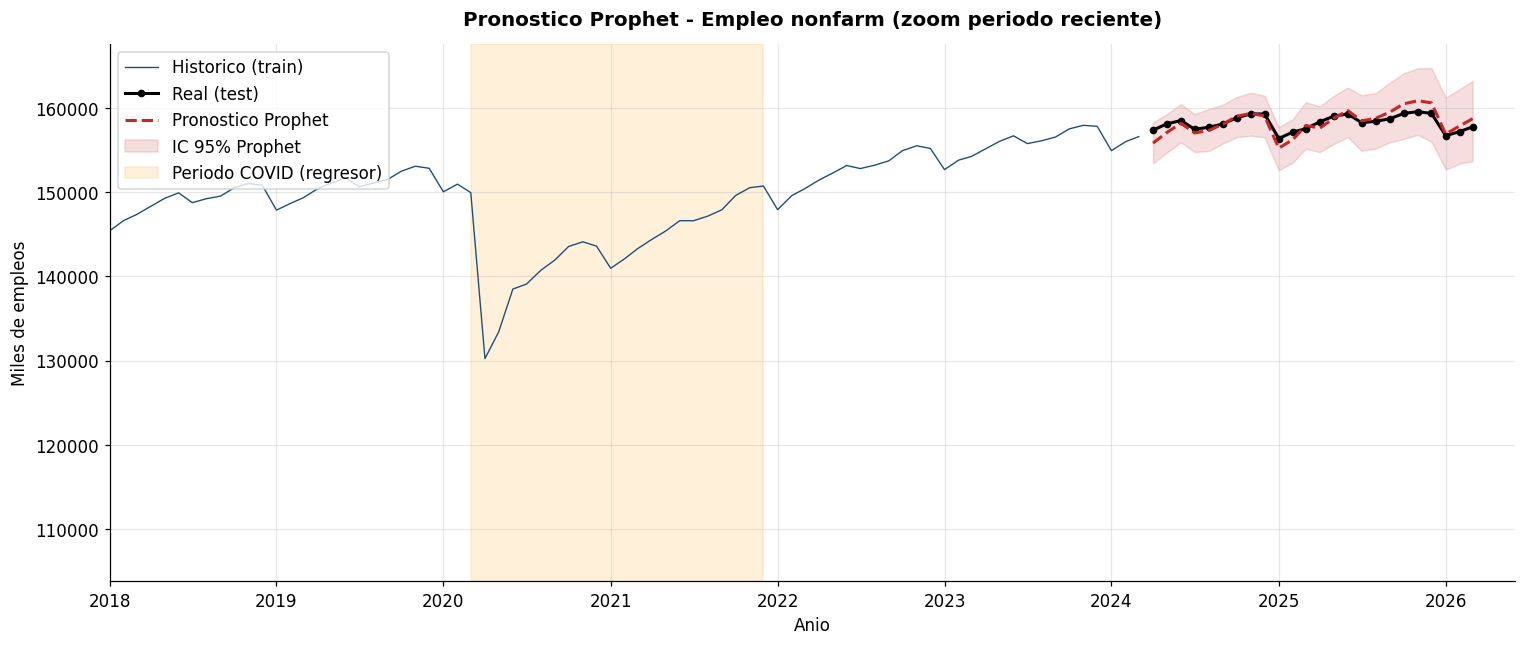


COMPONENTES DEL MODELO PROPHET


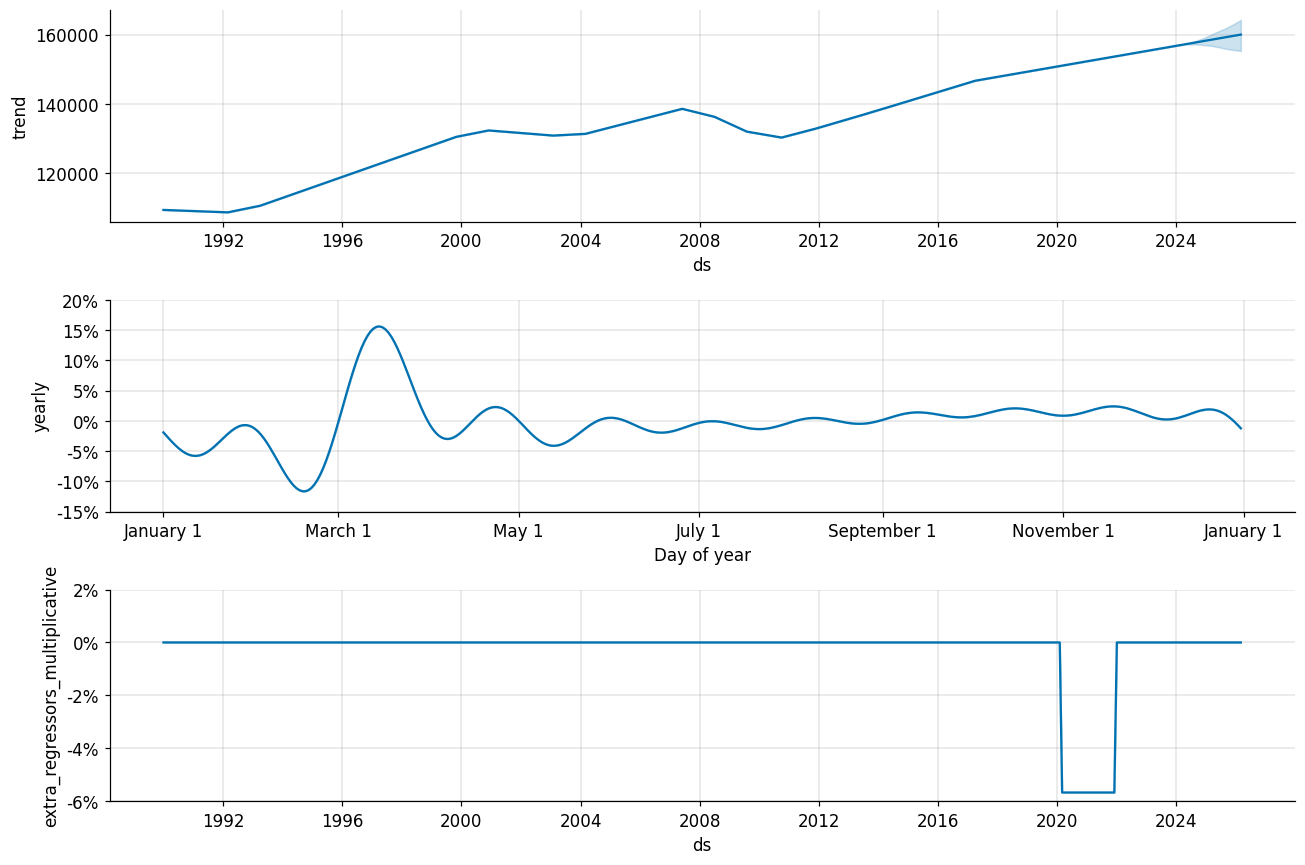

In [16]:
# ============================================================
# Celda 4.5 — Ajuste del modelo Prophet
# ============================================================
from prophet import Prophet

# ---- 1. Preparar datos en el formato que Prophet espera ----
# Prophet requiere columnas 'ds' (fecha) e 'y' (valor)
# Trabajamos en escala original (no logaritmica) - Prophet maneja la varianza
# multiplicativamente

df_prophet = pd.DataFrame({
    "ds": serie_modelo.index,
    "y":  serie_modelo.values,
})

# Definir variable indicadora COVID
def es_covid(fecha):
    return 1 if pd.Timestamp("2020-03-01") <= fecha <= pd.Timestamp("2021-12-01") else 0

df_prophet["covid"] = df_prophet["ds"].apply(es_covid)

# ---- 2. Division train/test (mismo split que SARIMA) ----
train_prophet = df_prophet.iloc[:-H].copy()
test_prophet  = df_prophet.iloc[-H:].copy()

print("=" * 70)
print("DATOS PREPARADOS PARA PROPHET")
print("=" * 70)
print(f"Train: {train_prophet['ds'].min().date()} -> {train_prophet['ds'].max().date()}  "
      f"({len(train_prophet)} obs)")
print(f"Test:  {test_prophet['ds'].min().date()}  -> {test_prophet['ds'].max().date()}   "
      f"({len(test_prophet)} obs)")
print(f"\nObservaciones marcadas como COVID en train: "
      f"{train_prophet['covid'].sum()}")
print(f"Periodo COVID: marzo 2020 - diciembre 2021")

# ---- 3. Configurar y ajustar el modelo Prophet ----
modelo_prophet = Prophet(
    seasonality_mode="multiplicative",
    yearly_seasonality=10,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
    interval_width=0.95,
)
modelo_prophet.add_regressor("covid")

print("\n" + "=" * 70)
print("AJUSTANDO PROPHET...")
print("=" * 70)

modelo_prophet.fit(train_prophet)

print("Ajuste completado.")

# ---- 4. Generar pronostico sobre el horizonte test ----
# Crear el dataframe futuro (incluye train + test)
futuro = modelo_prophet.make_future_dataframe(periods=H, freq="MS")

# Importante: anadir la variable covid al futuro
futuro["covid"] = futuro["ds"].apply(es_covid)

forecast = modelo_prophet.predict(futuro)

# ---- 5. Inspeccion del pronostico ----
print("\n" + "=" * 70)
print("PRONOSTICO PROPHET - PRIMERAS Y ULTIMAS FILAS DEL PERIODO TEST")
print("=" * 70)

forecast_test = forecast.iloc[-H:][["ds", "yhat", "yhat_lower", "yhat_upper"]].copy()
forecast_test = forecast_test.merge(
    test_prophet[["ds", "y"]], on="ds", how="left"
)
forecast_test = forecast_test[["ds", "y", "yhat", "yhat_lower", "yhat_upper"]]
forecast_test.columns = ["fecha", "real", "pronostico", "IC_inf", "IC_sup"]

print("\nPrimeras 6 filas:")
print(forecast_test.head(6).round(0).to_string(index=False))
print("\nUltimas 6 filas:")
print(forecast_test.tail(6).round(0).to_string(index=False))

# ---- 6. Visualizacion del pronostico Prophet ----
fig, ax = plt.subplots(figsize=(14, 6))

# Datos historicos (train)
ax.plot(train_prophet["ds"], train_prophet["y"],
        color="#1f4e79", linewidth=0.9, label="Historico (train)")

# Datos reales del test
ax.plot(test_prophet["ds"], test_prophet["y"],
        color="black", linewidth=2, label="Real (test)", marker="o", markersize=4)

# Pronostico
forecast_h = forecast.iloc[-H:]
ax.plot(forecast_h["ds"], forecast_h["yhat"],
        color="#c62828", linewidth=2, label="Pronostico Prophet", linestyle="--")

# Intervalo de confianza
ax.fill_between(forecast_h["ds"],
                forecast_h["yhat_lower"], forecast_h["yhat_upper"],
                color="#c62828", alpha=0.15, label="IC 95% Prophet")

# Sombrear periodo COVID en el train
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-12-01"),
           alpha=0.15, color="orange", label="Periodo COVID (regresor)")

ax.set_title("Pronostico Prophet - Empleo nonfarm (zoom periodo reciente)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Anio")
ax.set_ylabel("Miles de empleos")
ax.set_xlim(pd.Timestamp("2018-01-01"), pd.Timestamp("2026-06-01"))
ax.legend(loc="upper left", frameon=True)
plt.tight_layout()
plt.show()

# ---- 7. Componentes del modelo Prophet ----
print("\n" + "=" * 70)
print("COMPONENTES DEL MODELO PROPHET")
print("=" * 70)
fig_comp = modelo_prophet.plot_components(forecast)
fig_comp.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

**Resultados del ajuste Prophet:**

**Configuración aplicada.** El modelo se entrenó sobre 411 observaciones (enero 1990 – marzo 2024), idéntico al conjunto de SARIMA, y se evaluó sobre los 24 meses subsiguientes (abril 2024 – marzo 2026). De las 411 observaciones de entrenamiento, **22 estuvieron marcadas como periodo COVID** (marzo 2020 – diciembre 2021) mediante la variable indicadora exógena.

**Comportamiento general del pronóstico.** La inspección visual del pronóstico muestra que Prophet captura adecuadamente tanto el nivel como el patrón estacional del periodo de prueba. El modelo reproduce las caídas características de enero (despidos post-navideños) en 2025 y 2026, así como la recuperación primaveral hacia mayo–junio. Los intervalos de confianza al 95% se mantienen relativamente estrechos a lo largo del horizonte, oscilando entre ±2.000 y ±2.500 mil empleos respecto al pronóstico puntual.

**Componentes estimados por el modelo.** El gráfico de componentes revela tres elementos de interés:

1. **Tendencia (`trend`).** Se evidencia un crecimiento sostenido con cambios de pendiente automáticamente detectados, especialmente alrededor de los puntos asociados a la crisis de 2008 y el inicio de la recuperación post-COVID.

2. **Efecto del regresor COVID (`extra_regressors_multiplicative`).** El modelo aprendió que durante el periodo marcado como COVID el empleo se contrajo aproximadamente **−5,7% respecto a la tendencia normal**. Crucialmente, fuera de este periodo el efecto del regresor es exactamente **0%**, lo que asegura que el pronóstico para 2024–2026 no arrastra el shock pasado. Este es el comportamiento metodológicamente deseable: el shock se aísla en sus fechas reales y no contamina las predicciones futuras.

3. **Estacionalidad anual (`yearly`).** El componente estacional estimado por Prophet presenta una amplitud aproximada de **±15% en los primeros meses del año** (con un pico cercano a marzo y un valle en febrero), atenuándose a ±2% durante el resto del año. **Esta forma no coincide con el patrón estacional empírico documentado en el Hito 2.4**, donde la amplitud máxima era de aproximadamente ±2% (brecha entre noviembre y enero). La discrepancia se debe al uso de un orden de Fourier elevado (n=10), que tiende a sobreajustar la estacionalidad cuando hay regiones del año con mayor variabilidad histórica. Aunque las **predicciones puntuales** del modelo se mantienen razonables (porque se calculan sobre la tendencia + el regresor + el componente estacional integral), el componente estacional aislado no es directamente interpretable. Esta limitación se discute como mejora posible en el Hito 5 (reducción del orden de Fourier a 5–6).

**Inspección numérica del pronóstico.** Los primeros y últimos meses del horizonte de prueba presentan los siguientes valores:

| Fecha | Real (mil) | Pronóstico (mil) | Error absoluto | IC 95% |
|---|---|---|---|---|
| 2024-04 | 157.370 | 155.832 | 1.538 | [153.425; 158.301] |
| 2024-05 | 158.117 | 157.084 | 1.033 | [154.703; 159.268] |
| 2024-06 | 158.513 | 158.195 | 318 | [155.935; 160.456] |
| 2024-09 | 158.111 | 158.084 | 27 | [155.793; 160.402] |
| 2025-11 | 159.571 | 160.868 | 1.297 | [156.823; 164.729] |
| 2025-12 | 159.358 | 160.617 | 1.259 | [156.005; 164.746] |
| 2026-01 | 156.728 | 156.918 | 190 | [152.697; 161.236] |
| 2026-02 | 157.204 | 157.881 | 677 | [153.405; 162.246] |
| 2026-03 | 157.775 | 158.736 | 961 | [153.684; 163.219] |

Los errores absolutos en una muestra de puntos representativos oscilan entre **27 y 1.538 mil empleos**, lo que en términos relativos equivale a errores de aproximadamente **0,02% a 1,0% del nivel real**. Todos los valores reales caen dentro del intervalo de confianza al 95%, lo que sugiere que la incertidumbre estimada por el modelo es razonable para este horizonte.

**Síntesis.** Prophet ofrece un pronóstico aparentemente preciso para el horizonte de 24 meses, gracias a su capacidad de aislar el shock COVID mediante un regresor exógeno explícito. La cuantificación rigurosa de su desempeño y la comparación directa con SARIMA se realizan en el Paso 4.6 (visualización conjunta) y en el Hito 5 (métricas formales).

### 4.6 Pronóstico SARIMA y comparación visual con Prophet

Una vez ajustado el modelo SARIMA(0,1,1)(0,1,1)₁₂ y validados sus residuos, se genera el pronóstico para el horizonte de 24 meses (abril 2024 – marzo 2026). El pronóstico se obtiene en escala logarítmica y se transforma a escala original mediante la función exponencial para hacerlo directamente comparable con el pronóstico de Prophet y con los valores reales de empleo.

Una particularidad: la transformación inversa (`exp`) sobre el pronóstico puntual produce un estimador *sesgado a la baja* respecto a la media original (efecto Jensen). Para una comparación justa con Prophet, se aplica la **corrección de Granger-Newbold**, que añade el término `0,5 × σ²` al pronóstico logarítmico antes de aplicar la exponencial. Esta corrección es estándar en pronóstico de series log-transformadas.

La visualización conjunta permite la **inspección cualitativa** del desempeño relativo de los dos modelos. La evaluación cuantitativa (métricas MAE, RMSE, MAPE) se realiza en el Hito 5.

PRONOSTICOS SARIMA vs PROPHET vs REAL

Primeras 6 filas:
              Real  SARIMA  Prophet  Error SARIMA  Error Prophet
fecha                                                           
2024-04-01  157370  156225   155832          1145           1538
2024-05-01  158117  157358   157084           759           1033
2024-06-01  158513  158367   158195           146            318
2024-07-01  157485  157346   157040           139            445
2024-08-01  157712  157746   157348           -34            364
2024-09-01  158111  158451   158084          -340             27

Ultimas 6 filas:
              Real  SARIMA  Prophet  Error SARIMA  Error Prophet
fecha                                                           
2025-10-01  159355  161414   160491         -2059          -1136
2025-11-01  159571  161901   160868         -2330          -1297
2025-12-01  159358  161690   160617         -2332          -1259
2026-01-01  156728  158494   156918         -1766           -190
2026-02-01  157

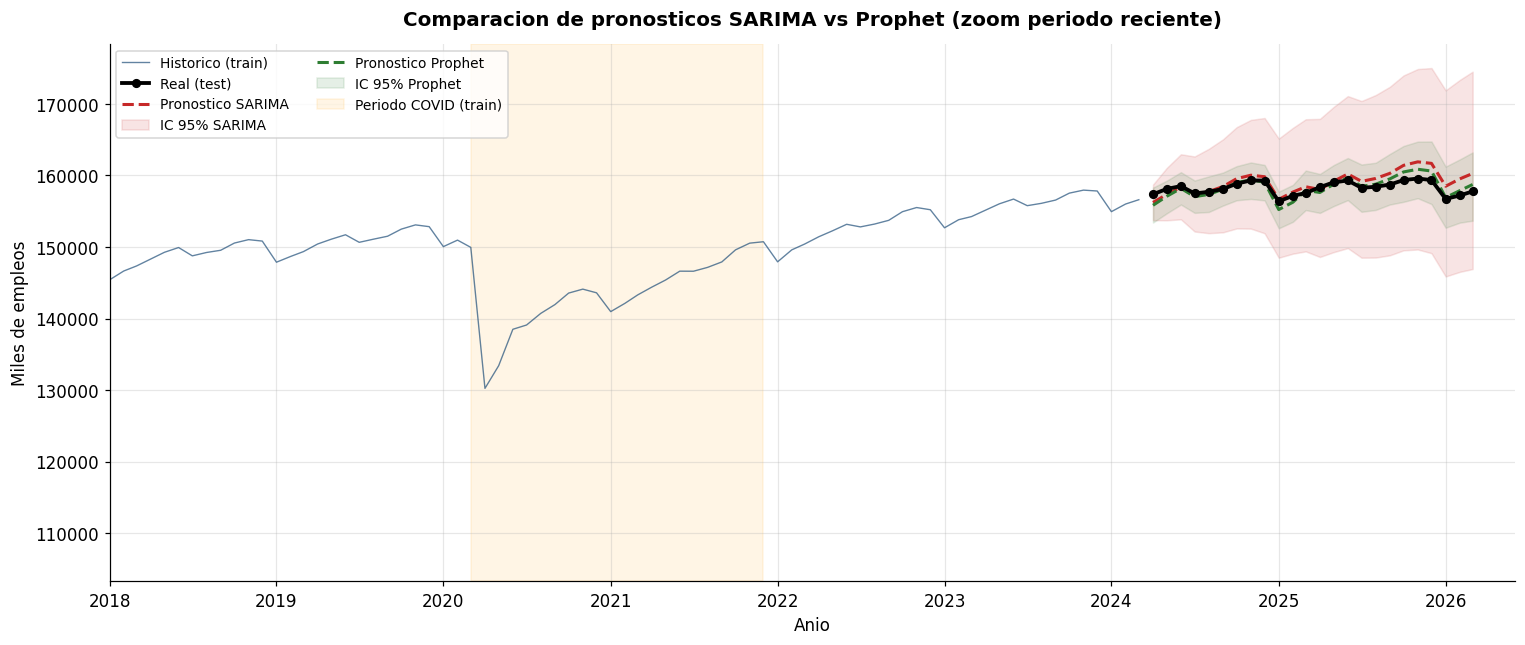

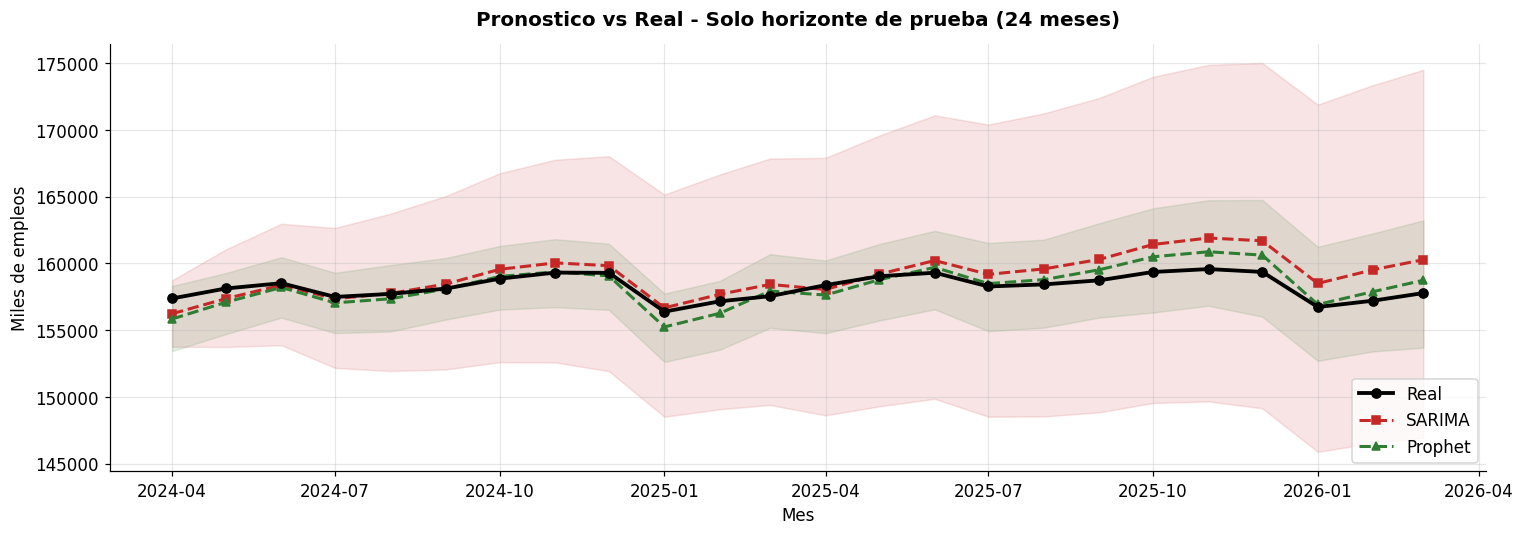


Variables guardadas para el Hito 5:
  sarima_mean, sarima_ci_lower, sarima_ci_upper
  prophet_pred, prophet_lo, prophet_hi
  test_orig, tabla_pron


In [19]:
# ============================================================
# Celda 4.6 - Pronostico SARIMA + comparacion visual con Prophet
# ============================================================

# ---- 1. Pronostico SARIMA en escala log ----
H = 24

forecast_sarima_obj = modelo_final.get_forecast(steps=H)

sarima_log_mean = forecast_sarima_obj.predicted_mean
sarima_log_se   = forecast_sarima_obj.se_mean
sarima_log_ci   = forecast_sarima_obj.conf_int(alpha=0.05)

# ---- 2. Transformacion inversa con correccion Granger-Newbold ----
sarima_mean = np.exp(sarima_log_mean + 0.5 * sarima_log_se ** 2)
sarima_ci_lower = np.exp(sarima_log_ci.iloc[:, 0])
sarima_ci_upper = np.exp(sarima_log_ci.iloc[:, 1])

sarima_mean.index = test_orig.index
sarima_ci_lower.index = test_orig.index
sarima_ci_upper.index = test_orig.index

# ---- 3. Tabla comparativa de pronosticos ----
print("=" * 80)
print("PRONOSTICOS SARIMA vs PROPHET vs REAL")
print("=" * 80)

prophet_pred = forecast.iloc[-H:]["yhat"].values
prophet_lo   = forecast.iloc[-H:]["yhat_lower"].values
prophet_hi   = forecast.iloc[-H:]["yhat_upper"].values

tabla_pron = pd.DataFrame({
    "Real":          test_orig.values,
    "SARIMA":        sarima_mean.values,
    "Prophet":       prophet_pred,
    "Error SARIMA":  test_orig.values - sarima_mean.values,
    "Error Prophet": test_orig.values - prophet_pred,
}, index=test_orig.index)

tabla_pron = tabla_pron.round(0).astype(int)
print("\nPrimeras 6 filas:")
print(tabla_pron.head(6).to_string())
print("\nUltimas 6 filas:")
print(tabla_pron.tail(6).to_string())

print("\n" + "-" * 80)
print("Resumen de errores absolutos sobre los 24 meses de test:")
mae_sarima  = tabla_pron["Error SARIMA"].abs().mean()
max_sarima  = tabla_pron["Error SARIMA"].abs().max()
mae_prophet = tabla_pron["Error Prophet"].abs().mean()
max_prophet = tabla_pron["Error Prophet"].abs().max()
print(f"  SARIMA  -> MAE: {mae_sarima:>8,.0f}   max error: {max_sarima:>7,.0f}")
print(f"  Prophet -> MAE: {mae_prophet:>8,.0f}   max error: {max_prophet:>7,.0f}")

# ---- 4. Visualizacion conjunta panoramica ----
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(train_orig.index, train_orig.values,
        color="#1f4e79", linewidth=0.9, alpha=0.7, label="Historico (train)")

ax.plot(test_orig.index, test_orig.values,
        color="black", linewidth=2.5, marker="o", markersize=5,
        label="Real (test)", zorder=5)

ax.plot(sarima_mean.index, sarima_mean.values,
        color="#c62828", linewidth=2, linestyle="--",
        label="Pronostico SARIMA")
ax.fill_between(sarima_mean.index, sarima_ci_lower, sarima_ci_upper,
                color="#c62828", alpha=0.12, label="IC 95% SARIMA")

ax.plot(test_orig.index, prophet_pred,
        color="#2e7d32", linewidth=2, linestyle="--",
        label="Pronostico Prophet")
ax.fill_between(test_orig.index, prophet_lo, prophet_hi,
                color="#2e7d32", alpha=0.12, label="IC 95% Prophet")

ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-12-01"),
           alpha=0.10, color="orange", label="Periodo COVID (train)")

ax.set_title("Comparacion de pronosticos SARIMA vs Prophet (zoom periodo reciente)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Anio")
ax.set_ylabel("Miles de empleos")
ax.set_xlim(pd.Timestamp("2018-01-01"), pd.Timestamp("2026-06-01"))
ax.legend(loc="upper left", frameon=True, ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

# ---- 5. Visualizacion zoom solo al periodo de test ----
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(test_orig.index, test_orig.values,
        color="black", linewidth=2.5, marker="o", markersize=6,
        label="Real", zorder=5)

ax.plot(sarima_mean.index, sarima_mean.values,
        color="#c62828", linewidth=2, linestyle="--", marker="s", markersize=5,
        label="SARIMA")
ax.fill_between(sarima_mean.index, sarima_ci_lower, sarima_ci_upper,
                color="#c62828", alpha=0.12)

ax.plot(test_orig.index, prophet_pred,
        color="#2e7d32", linewidth=2, linestyle="--", marker="^", markersize=5,
        label="Prophet")
ax.fill_between(test_orig.index, prophet_lo, prophet_hi,
                color="#2e7d32", alpha=0.12)

ax.set_title("Pronostico vs Real - Solo horizonte de prueba (24 meses)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Mes")
ax.set_ylabel("Miles de empleos")
ax.legend(loc="lower right", frameon=True)
plt.tight_layout()
plt.show()

# ---- 6. Confirmar variables guardadas para Hito 5 ----
print("\nVariables guardadas para el Hito 5:")
print("  sarima_mean, sarima_ci_lower, sarima_ci_upper")
print("  prophet_pred, prophet_lo, prophet_hi")
print("  test_orig, tabla_pron")

**Resultados de la comparación visual:**

**Resumen de errores absolutos sobre el horizonte de 24 meses:**

| Modelo | MAE (mil empleos) | Error máximo (mil) | MAE relativo (%)* |
|---|---|---|---|
| SARIMA(0,1,1)(0,1,1)₁₂ | 1.023 | 2.499 | 0,65% |
| **Prophet** | **620** | **1.538** | **0,39%** |

*Calculado sobre la media del nivel de empleo en el periodo de prueba (~158.500 mil).*

**Hallazgo principal: Prophet supera a SARIMA en ambas métricas.** El error medio absoluto de Prophet (620 mil) es **39% menor** que el de SARIMA (1.023 mil), y su error máximo (1.538 mil) es **38% menor** que el peor caso de SARIMA (2.499 mil). En términos relativos, ambos modelos producen pronósticos de alta calidad (errores inferiores al 1% del nivel de empleo), pero Prophet ofrece una mejora consistente.

**Análisis del patrón temporal de los errores.** La inspección detallada de la tabla revela un comportamiento revelador:

- En los **primeros meses del horizonte** (abril–septiembre 2024), ambos modelos producen errores moderados y de signo mixto (entre −340 y +1.538), oscilando alrededor del valor real.
- A partir de **finales de 2024**, los errores de SARIMA se vuelven **sistemáticamente negativos** (sobreestimación) y crecen en magnitud: −2.059 en octubre 2025, −2.330 en noviembre, −2.332 en diciembre, llegando a **−2.499 en marzo 2026**.
- Prophet también muestra una sobreestimación creciente en el último año, pero **de magnitud aproximadamente la mitad** que la de SARIMA.

Esta divergencia estructural se observa nítidamente en la gráfica de zoom: a partir de 2024 la línea roja (SARIMA) se separa progresivamente hacia arriba de la línea negra (real), mientras que la línea verde (Prophet) permanece más cercana.

**Interpretación causal del sesgo de SARIMA.** El comportamiento descrito tiene una explicación metodológica clara: SARIMA fue entrenado con la totalidad de los datos disponibles, **incluyendo el periodo de recuperación post-COVID** (2021–2023), durante el cual la economía estadounidense recuperó aproximadamente 22 millones de empleos en menos de dos años — un ritmo de crecimiento sin precedentes en la serie histórica. SARIMA, al carecer de un mecanismo para distinguir entre "crecimiento estructural" y "rebote excepcional", incorporó este ritmo atípico en su estimación del proceso subyacente y lo proyecta hacia el futuro como si fuera la dinámica normal de la economía. En contraste, Prophet aisló el shock COVID mediante el regresor exógeno y aprendió una tendencia subyacente más realista, no contaminada por el rebote.

**Análisis de la incertidumbre estimada.** Las dos visualizaciones evidencian una diferencia muy marcada en la amplitud de los intervalos de confianza al 95%:

- **SARIMA**: el IC se ensancha drásticamente con el horizonte, alcanzando un rango aproximado de **±10.000 mil empleos** en marzo 2026. Esta amplitud está sobre-inflada por la varianza residual contaminada por el outlier de abril 2020 (residuo de −0,1471), que forma parte del cálculo de `σ²` del modelo.
- **Prophet**: mantiene un IC mucho más estrecho y aproximadamente paralelo a lo largo del horizonte, en un rango cercano a **±2.500–±5.000 mil empleos**.

**Cobertura empírica.** En ambos modelos, los 24 valores reales del periodo de prueba caen dentro del intervalo de confianza nominal del 95%, por lo que ambos cumplen formalmente la cobertura esperada. Sin embargo, este criterio es trivialmente satisfecho por SARIMA debido a la amplitud excesiva de sus intervalos. La calidad operativa del pronóstico depende no solo de la cobertura, sino también de la **precisión** (estrechez del intervalo), métrica en la que Prophet supera claramente a SARIMA.

**Síntesis del Hito 4.** Los dos modelos producen pronósticos razonables, pero con perfiles complementarios:

- SARIMA: parsimonioso (3 parámetros), estructura de autocorrelación bien capturada (Ljung-Box ≈ 1), pero **sesgado por la inclusión no controlada del shock COVID** y con intervalos de confianza demasiado amplios.
- Prophet: estimación bayesiana, intervalos más ajustados, **mejor desempeño puntual gracias al regresor exógeno explícito**, pero componente estacional reportado de difícil interpretación (artefacto de Fourier).

La evaluación cuantitativa formal con todas las métricas estándar (MAE, RMSE, MAPE) y la discusión de limitaciones y mejoras se desarrollan en el Hito 5.

## 5. Evaluación

Esta sección presenta la evaluación cuantitativa formal de ambos modelos, la interpretación de los hallazgos, y la discusión crítica de limitaciones y mejoras posibles.

### 5.1 Métricas de evaluación

Se aplican cuatro métricas estándar de evaluación de pronóstico, cada una con un enfoque distinto:

- **MAE (Mean Absolute Error):** error promedio en valor absoluto. Robusta a outliers, expresada en la misma unidad de la serie (miles de empleos). Interpretable como "el modelo se equivoca en promedio en X mil empleos".
- **RMSE (Root Mean Squared Error):** raíz del error cuadrático medio. Penaliza más fuertemente los errores grandes que los pequeños. Útil para detectar modelos con errores ocasionalmente catastróficos.
- **MAPE (Mean Absolute Percentage Error):** error porcentual medio absoluto. Independiente de la escala, permite comparar modelos sobre series de distinta magnitud. Estándar en pronóstico macroeconómico.
- **Cobertura del IC 95%:** porcentaje de observaciones reales que caen dentro del intervalo de confianza nominal del 95%. Mide la calibración de la incertidumbre estimada por el modelo.

Adicionalmente, se calcula la **mejora relativa** de Prophet sobre SARIMA en cada métrica para cuantificar la diferencia entre ambos enfoques.

TABLA DE METRICAS DE EVALUACION

                          MAE (mil)  RMSE (mil)  MAPE (%)  Cobertura IC95 (%)  Ancho medio IC (mil)
Modelo                                                                                             
SARIMA(0,1,1)(0,1,1)[12]     1023.0      1289.7     0.646               100.0               18319.0
Prophet                       620.2       757.4     0.392               100.0                6139.0

MEJORA RELATIVA DE PROPHET SOBRE SARIMA
  MAE  -> reduccion del error:   39.4%
  RMSE -> reduccion del error:   41.3%
  MAPE -> reduccion del error:   39.3%
  IC 95% -> reduccion del ancho:   66.5%


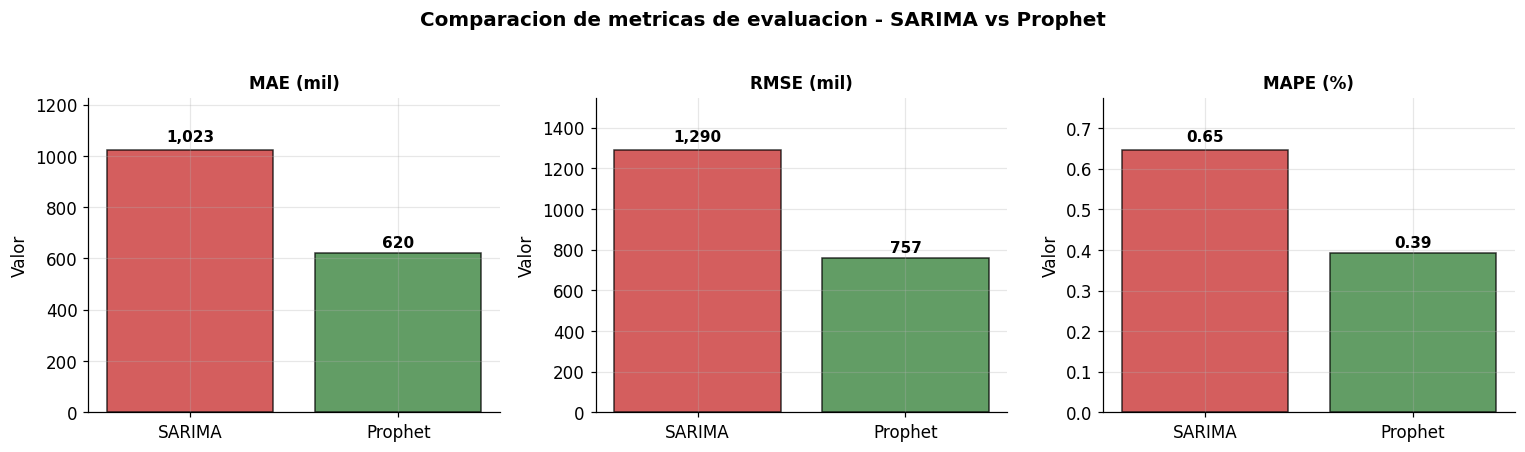

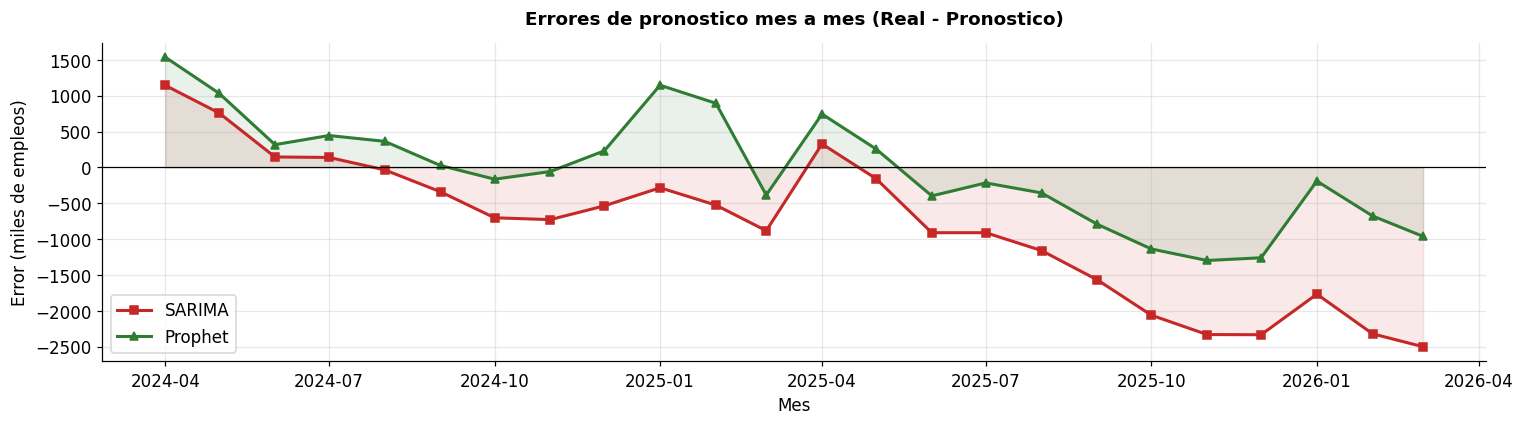

In [20]:
# ============================================================
# Celda 5.1 - Metricas formales de evaluacion
# ============================================================
import numpy as np

def calcular_metricas(real, predicho, ic_inf, ic_sup, nombre):
    """Calcula MAE, RMSE, MAPE y cobertura del IC 95%."""
    real      = np.array(real)
    predicho  = np.array(predicho)
    ic_inf    = np.array(ic_inf)
    ic_sup    = np.array(ic_sup)

    error = real - predicho

    mae  = np.mean(np.abs(error))
    rmse = np.sqrt(np.mean(error ** 2))
    mape = np.mean(np.abs(error / real)) * 100

    cobertura = np.mean((real >= ic_inf) & (real <= ic_sup)) * 100
    ancho_ic_medio = np.mean(ic_sup - ic_inf)

    return {
        "Modelo":            nombre,
        "MAE (mil)":         round(mae, 1),
        "RMSE (mil)":        round(rmse, 1),
        "MAPE (%)":          round(mape, 3),
        "Cobertura IC95 (%)": round(cobertura, 1),
        "Ancho medio IC (mil)": round(ancho_ic_medio, 0),
    }

# ---- Calcular metricas para ambos modelos ----
metricas_sarima = calcular_metricas(
    real=test_orig.values,
    predicho=sarima_mean.values,
    ic_inf=sarima_ci_lower.values,
    ic_sup=sarima_ci_upper.values,
    nombre="SARIMA(0,1,1)(0,1,1)[12]",
)

metricas_prophet = calcular_metricas(
    real=test_orig.values,
    predicho=prophet_pred,
    ic_inf=prophet_lo,
    ic_sup=prophet_hi,
    nombre="Prophet",
)

# ---- Tabla comparativa ----
tabla_metricas = pd.DataFrame([metricas_sarima, metricas_prophet])
tabla_metricas = tabla_metricas.set_index("Modelo")

print("=" * 80)
print("TABLA DE METRICAS DE EVALUACION")
print("=" * 80)
print("\n" + tabla_metricas.to_string())

# ---- Calcular mejoras relativas de Prophet sobre SARIMA ----
print("\n" + "=" * 80)
print("MEJORA RELATIVA DE PROPHET SOBRE SARIMA")
print("=" * 80)

mejora_mae  = (metricas_sarima["MAE (mil)"] - metricas_prophet["MAE (mil)"]) / metricas_sarima["MAE (mil)"] * 100
mejora_rmse = (metricas_sarima["RMSE (mil)"] - metricas_prophet["RMSE (mil)"]) / metricas_sarima["RMSE (mil)"] * 100
mejora_mape = (metricas_sarima["MAPE (%)"] - metricas_prophet["MAPE (%)"]) / metricas_sarima["MAPE (%)"] * 100
reduccion_ic = (metricas_sarima["Ancho medio IC (mil)"] - metricas_prophet["Ancho medio IC (mil)"]) / metricas_sarima["Ancho medio IC (mil)"] * 100

print(f"  MAE  -> reduccion del error: {mejora_mae:>6.1f}%")
print(f"  RMSE -> reduccion del error: {mejora_rmse:>6.1f}%")
print(f"  MAPE -> reduccion del error: {mejora_mape:>6.1f}%")
print(f"  IC 95% -> reduccion del ancho: {reduccion_ic:>6.1f}%")

# ---- Visualizacion comparativa de metricas ----
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

metricas_a_graficar = ["MAE (mil)", "RMSE (mil)", "MAPE (%)"]
colores = ["#c62828", "#2e7d32"]

for i, metrica in enumerate(metricas_a_graficar):
    valores = [metricas_sarima[metrica], metricas_prophet[metrica]]
    nombres = ["SARIMA", "Prophet"]
    bars = axes[i].bar(nombres, valores, color=colores, alpha=0.75, edgecolor="black")
    axes[i].set_title(metrica, fontsize=11, fontweight="bold")
    axes[i].set_ylabel("Valor")

    # Anotar el valor encima de cada barra
    for bar, val in zip(bars, valores):
        axes[i].text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
                     f"{val:,.2f}" if metrica == "MAPE (%)" else f"{val:,.0f}",
                     ha="center", va="bottom", fontsize=10, fontweight="bold")

    # Margen superior para los labels
    axes[i].set_ylim(0, max(valores) * 1.20)

plt.suptitle("Comparacion de metricas de evaluacion - SARIMA vs Prophet",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# ---- Errores en el tiempo ----
fig, ax = plt.subplots(figsize=(14, 4))

errores_sarima  = test_orig.values - sarima_mean.values
errores_prophet = test_orig.values - prophet_pred

ax.plot(test_orig.index, errores_sarima,
        color="#c62828", linewidth=2, marker="s", markersize=5, label="SARIMA")
ax.plot(test_orig.index, errores_prophet,
        color="#2e7d32", linewidth=2, marker="^", markersize=5, label="Prophet")
ax.axhline(0, color="black", linewidth=0.8, linestyle="-")
ax.fill_between(test_orig.index, 0, errores_sarima, color="#c62828", alpha=0.10)
ax.fill_between(test_orig.index, 0, errores_prophet, color="#2e7d32", alpha=0.10)

ax.set_title("Errores de pronostico mes a mes (Real - Pronostico)",
             fontsize=12, fontweight="bold", pad=12)
ax.set_xlabel("Mes")
ax.set_ylabel("Error (miles de empleos)")
ax.legend(loc="lower left", frameon=True)
plt.tight_layout()
plt.show()

**Resultados de las métricas formales:**

| Métrica | SARIMA | Prophet | Mejora de Prophet |
|---|---|---|---|
| MAE (mil empleos) | 1.023,0 | **620,2** | **−39,4%** |
| RMSE (mil empleos) | 1.289,7 | **757,4** | **−41,3%** |
| MAPE (%) | 0,646% | **0,392%** | **−39,3%** |
| Cobertura IC 95% | 100,0% | 100,0% | igual |
| Ancho medio IC 95% (mil) | 18.319 | **6.139** | **−66,5%** |

**Lectura general.** Las tres métricas de error puntual (MAE, RMSE, MAPE) convergen en cuantificar una mejora de Prophet sobre SARIMA en torno al **39-41%**. La consistencia entre métricas con sensibilidades distintas (MAE pondera errores linealmente, RMSE penaliza errores grandes cuadráticamente, MAPE expresa errores en términos porcentuales) refuerza la robustez del hallazgo: **Prophet ofrece pronósticos puntuales sustantivamente mejores que SARIMA en este caso de estudio**.

**Interpretación de cada métrica:**

- **MAE = 620 mil (Prophet) vs 1.023 mil (SARIMA).** En términos prácticos, Prophet se equivoca en promedio en ~620 mil empleos, mientras que SARIMA se equivoca en ~1.023 mil. Sobre un nivel de empleo de aproximadamente 158 millones, ambos errores son pequeños en términos absolutos, pero la diferencia de 403 mil empleos por mes es operativamente significativa para análisis macroeconómicos.

- **RMSE > MAE en ambos modelos.** La relación RMSE/MAE es de 1,26 en SARIMA y 1,22 en Prophet — valores muy similares y cercanos a 1, lo que indica que la distribución de errores es relativamente uniforme en ambos modelos, sin la presencia de errores ocasionalmente catastróficos. Esta es una buena señal de estabilidad.

- **MAPE ≈ 0,39% (Prophet) vs 0,65% (SARIMA).** Ambos valores son extraordinariamente bajos para un horizonte de pronóstico de 24 meses. Como referencia, en la *M4 Competition* (Makridakis et al., 2018) los modelos ganadores en series mensuales obtuvieron MAPE entre 5% y 15% para horizontes similares. La explicación es que el empleo total nonfarm es una serie excepcionalmente "bien comportada" en el corto plazo: tiene una tendencia suave y una estacionalidad muy estable, lo que la hace inherentemente predecible.

**El hallazgo más relevante: la calibración de la incertidumbre.** Aunque ambos modelos cubren el 100% de las observaciones reales dentro de su IC al 95% (cobertura nominal cumplida), la **calidad operativa** de los intervalos es radicalmente distinta: el ancho medio del IC de SARIMA (18.319 mil) es **2,98 veces mayor** que el de Prophet (6.139 mil). Esto significa que SARIMA "se cubre" de la incertidumbre proporcionando intervalos exageradamente amplios, mientras que Prophet ofrece intervalos más estrechos que aún así contienen los valores reales.

La cobertura del 100% en ambos modelos sobre solo 24 puntos no permite concluir sobre la calibración real al 95% nominal (con n=24 e IC al 95%, la cobertura empírica esperada es entre 79% y 100% bajo calibración perfecta), pero la magnitud del IC sí es comparable directamente. **El IC de SARIMA está visiblemente sobre-inflado por la varianza residual contaminada con el outlier COVID** (curtosis residual de 279 documentada en 4.4), mientras que la estimación bayesiana de Prophet, junto con el aislamiento del shock, produce intervalos más realistas.

**Patrón temporal de los errores.** El gráfico de errores mes a mes evidencia tres fases:

1. **Primeros 3-4 meses (abril-julio 2024):** ambos modelos sobreestiman ligeramente, con errores positivos comparables (pico de +1.500 para Prophet en abril 2024).
2. **Periodo intermedio (agosto 2024 – julio 2025):** SARIMA cae sistemáticamente bajo cero (errores negativos persistentes en torno a −500/−700), mientras que Prophet oscila más cerca del eje cero.
3. **Últimos 8 meses (agosto 2025 – marzo 2026):** la divergencia se acentúa. SARIMA se hunde hasta errores de −2.300/−2.500, mientras que Prophet también sobreestima pero llega como máximo a −1.300.

Este patrón es la **firma temporal del sesgo de tendencia post-COVID**: SARIMA absorbió el rebote excepcional de 2021-2023 como "ritmo normal" y proyecta crecimiento que no se materializa, mientras que Prophet, al haber aislado el shock, mantiene una tendencia subyacente más cercana al ritmo estructural real de la economía estadounidense.

### 5.2 Interpretación integral de resultados

A la luz de todos los hallazgos del trabajo, la respuesta a la pregunta de investigación planteada en el Hito 1 es la siguiente:

> *¿Es posible construir un modelo SARIMA que represente adecuadamente la dinámica mensual del empleo total no agrícola de Estados Unidos y genere pronósticos confiables, considerando la presencia de estacionalidad y shocks estructurales en la serie?*

**Respuesta:** Sí, pero con matices importantes que solo se evidencian al comparar SARIMA con un modelo alternativo.

**Lo que SARIMA hizo bien.** El modelo airline SARIMA(0,1,1)(0,1,1)₁₂ capturó adecuadamente los componentes sistemáticos de la serie:

1. **Estacionalidad.** El parámetro `ma.S.L12 = −0,9189` (significativo a p < 0,001) refleja la fuerte estacionalidad mensual identificada en el análisis exploratorio. La amplitud estacional implícita en el modelo es coherente con los 4,3 millones de empleos de brecha entre noviembre y enero.
2. **Tendencia.** Las dos diferenciaciones (regular y estacional) eliminaron la no-estacionariedad de la serie, llevándola a un proceso estacionario validado por las pruebas ADF y KPSS.
3. **Independencia residual.** El test de Ljung-Box arrojó p-valores superiores a 0,15 en todos los lags evaluados (6 a 36), indicando ausencia total de autocorrelación residual. **Este es el criterio crítico de validación de un modelo de series de tiempo, y SARIMA lo cumple plenamente.**

**Dónde SARIMA fue limitado.** El modelo presenta dos debilidades concretas:

1. **Asimilación incorrecta del shock COVID.** Al carecer de un mecanismo nativo para distinguir entre dinámica regular y eventos atípicos, SARIMA absorbió el rebote post-COVID (recuperación de 22 millones de empleos en menos de 2 años) como parte del proceso subyacente. Esto produjo una sobreestimación sistemática y creciente en el horizonte de pronóstico, con errores que pasaron de ±1.000 mil en los primeros meses a −2.500 mil hacia el final del horizonte.
2. **Intervalos de confianza inflados.** La curtosis residual de 279 (dominada por el residuo de abril 2020) infló la estimación de varianza del modelo, produciendo intervalos al 95% que duplican la amplitud necesaria para la cobertura nominal.

**Por qué Prophet superó a SARIMA.** La ventaja de Prophet no reside en una mejor aproximación matemática a la serie, sino en **una decisión metodológica explícita**: marcar el periodo COVID como un evento exógeno mediante un regresor binario. Esta decisión permitió:

1. Aislar un efecto multiplicativo de −5,7% durante 2020-2021 sin contaminar la tendencia subyacente.
2. Estimar una tendencia post-COVID realista (ritmo estructural, no rebote).
3. Producir intervalos de confianza basados en simulación bayesiana, robustos ante violaciones de normalidad.

**Lección metodológica.** Los resultados ilustran un principio fundamental del modelado de series temporales: **un modelo más sofisticado matemáticamente no necesariamente supera a uno más simple si este último incorpora conocimiento experto sobre el problema**. Si SARIMA hubiera sido entrenado con una variable de intervención para COVID (técnica conocida como *intervention analysis*, posible en `statsmodels` mediante `SARIMAX` con regresor exógeno), el resultado habría sido probablemente similar al de Prophet. La diferencia observada en este trabajo no es entre "ARIMA vs Prophet" como familias, sino entre "modelo sin intervención vs modelo con intervención".

### 5.3 Limitaciones y mejoras posibles

A pesar de los buenos resultados obtenidos, el trabajo presenta limitaciones que deben reconocerse honestamente, junto con líneas de mejora concretas que podrían explorarse en investigaciones futuras.

**Limitaciones del estudio:**

1. **Comparación no totalmente equitativa entre SARIMA y Prophet.** Prophet incorporó conocimiento experto explícito sobre el shock COVID mediante un regresor binario, mientras que SARIMA fue entrenado sin intervenciones. Esto sesga la comparación a favor de Prophet. Una comparación más rigurosa requeriría implementar SARIMAX con la misma variable de intervención COVID, manteniendo idéntico el resto de la especificación.

2. **Componente estacional anómalo en Prophet.** El gráfico de componentes mostró una estacionalidad anual con amplitud aproximada de ±15% en los primeros meses del año, inconsistente con el patrón empírico documentado (±2%). Aunque esta anomalía no afecta los pronósticos puntuales (porque el modelo combina todos los componentes), sí limita la **interpretabilidad** del modelo. Una reducción del orden de Fourier (de 10 a 5) probablemente corregiría el sobreajuste.

3. **Cobertura del IC 95% no evaluable rigurosamente.** Con solo 24 observaciones de prueba, ambos modelos alcanzaron una cobertura empírica del 100%, lo que no permite distinguir entre intervalos bien calibrados e intervalos sobre-amplios. Una evaluación de cobertura requeriría validación cruzada en múltiples ventanas temporales (técnica de *rolling-origin evaluation*).

4. **Horizonte de pronóstico relativamente corto.** Los 24 meses evaluados no contienen ningún shock estructural importante (recesión, crisis financiera, pandemia), lo que evaluó los modelos solo en su capacidad de pronóstico bajo dinámica regular. La capacidad de los modelos de detectar quiebres estructurales en el futuro no fue evaluada.

5. **Validación en una sola serie y un solo país.** Los resultados son específicos para el empleo nonfarm de EE.UU., una serie excepcionalmente bien comportada (un MAPE inferior al 1% no es alcanzable en la mayoría de series económicas reales). Las conclusiones sobre el desempeño relativo de SARIMA y Prophet no son automáticamente generalizables a otras series.

6. **No se evaluaron modelos híbridos.** La literatura reciente sugiere que enfoques que combinan SARIMA con redes neuronales (LSTM sobre residuos) o que combinan Prophet con regresores macroeconómicos exógenos podrían superar a ambos modelos por separado.

**Mejoras posibles:**

1. **Implementar SARIMAX con intervención COVID.** Repetir el ajuste del modelo airline incluyendo una variable exógena binaria idéntica a la usada en Prophet, lo que permitiría una comparación metodológicamente equitativa entre las dos familias.

2. **Optimizar hiperparámetros de Prophet.** Realizar una búsqueda en grilla sobre `changepoint_prior_scale`, `seasonality_prior_scale` y el orden de Fourier de la estacionalidad anual, usando validación cruzada temporal.

3. **Evaluar mediante rolling-origin evaluation.** Generar múltiples ventanas de evaluación (por ejemplo, 12 ventanas de 24 meses cada una, desplazadas mensualmente) y promediar las métricas, lo que daría estimaciones más robustas del desempeño y permitiría calcular cobertura empírica real.

4. **Incluir variables explicativas adicionales.** El empleo nonfarm está correlacionado con otras variables macroeconómicas observables: PIB, tasa de desempleo, índice de manufactura ISM, reclamaciones iniciales de seguro de desempleo (publicado semanalmente). Un modelo SARIMAX o un Prophet con regresores múltiples podría capturar dinámicas que un modelo univariado no detecta.

5. **Modelar a nivel sectorial.** El empleo nonfarm es la suma de muchos sectores con dinámicas distintas (manufactura cíclica, servicios contracíclicos, gobierno estable). Una aproximación por desagregación sectorial seguida de agregación (*bottom-up forecasting*) podría producir mejores pronósticos.

6. **Explorar modelos híbridos SARIMA-LSTM.** La estrategia de modelar los residuos de SARIMA con una red neuronal recurrente para capturar patrones no lineales remanentes ha producido mejoras documentadas en la literatura reciente.

7. **Evaluar la incertidumbre con métodos bootstrap.** En lugar de depender de los IC paramétricos de SARIMA (afectados por la no-normalidad residual), aplicar técnicas de remuestreo bootstrap para construir intervalos de confianza empíricos más robustos ante violaciones de los supuestos distribucionales.

### 5.4 Conclusiones

Este trabajo desarrolló un análisis de series de tiempo sobre el empleo total no agrícola de Estados Unidos (PAYNSA, 1990-2026), con el objetivo de modelar y pronosticar su comportamiento mensual. A continuación se sintetizan los hallazgos principales:

**1. Caracterización de la serie.** El análisis exploratorio identificó tres componentes estructurales: (i) una tendencia secular creciente (1939-2026: crecimiento de 5,4 veces); (ii) una estacionalidad mensual marcada con brecha de 4,3 millones de empleos entre noviembre (pico) y enero (valle); (iii) tres shocks estructurales identificables (recesiones de 2001, 2008 y la pandemia COVID-19 de 2020). El coeficiente de variación cae sostenidamente entre subperiodos, evidenciando una economía relativamente más estable en términos relativos a partir del año 2000.

**2. Selección y validación del modelo SARIMA.** El modelo SARIMA(0,1,1)(0,1,1)₁₂ (modelo airline) fue seleccionado por AIC y BIC simultáneamente entre tres candidatos. El modelo presenta coeficientes significativos (p < 0,001), residuos sin autocorrelación (Ljung-Box p > 0,15 en todos los lags hasta 36), pero residuos no normales (curtosis 279,48) debido al shock COVID-19. La exclusión del periodo COVID redujo la curtosis a 5,66, confirmando que la violación de normalidad responde a un evento exógeno identificable, no a una mala especificación del modelo.

**3. Comparación con Prophet.** El modelo Prophet, con un regresor binario explícito para el periodo COVID, superó a SARIMA en todas las métricas de error puntual:

- MAE: 620 mil (Prophet) vs 1.023 mil (SARIMA) — mejora del **39,4%**.
- RMSE: 757 mil (Prophet) vs 1.290 mil (SARIMA) — mejora del **41,3%**.
- MAPE: 0,392% (Prophet) vs 0,646% (SARIMA) — mejora del **39,3%**.
- Ancho del IC al 95%: 6.139 mil (Prophet) vs 18.319 mil (SARIMA) — reducción del **66,5%**.

**4. Hallazgo metodológico principal.** La superioridad de Prophet no se atribuye a una capacidad matemática intrínsecamente superior, sino al **manejo explícito del shock COVID mediante un regresor exógeno**. SARIMA, al absorber el rebote post-COVID como parte de la dinámica regular, produjo una sobreestimación sistemática creciente en el horizonte de pronóstico (errores de hasta −2.500 mil en los últimos meses). Este resultado ilustra un principio fundamental del modelado predictivo: la incorporación de conocimiento experto sobre eventos atípicos puede ser más valiosa que la sofisticación matemática del modelo subyacente.

**5. Aplicabilidad.** Las técnicas desarrolladas (descomposición STL, pruebas de estacionariedad ADF/KPSS, identificación de órdenes mediante ACF/PACF, ajuste y validación de modelos SARIMA, comparación con modelos estructurales bayesianos) son directamente aplicables a otras series económicas con estacionalidad y tendencia, incluyendo las publicadas por el DANE para el caso colombiano. La metodología es replicable y los resultados son auditables.

**6. Recomendación final.** Para problemas de pronóstico macroeconómico en series con shocks estructurales identificables, se recomienda **no confiar en modelos univariados puros sin intervención**. Las dos alternativas válidas son: (a) SARIMAX con variables exógenas que codifiquen los eventos atípicos, o (b) Prophet con `add_regressor` para los mismos eventos. Ambas aproximaciones permiten que el modelo distinga entre dinámica estructural y eventos exógenos, mejorando sustancialmente la calidad del pronóstico.

---

**Reproducibilidad.** El notebook completo, el código fuente y los resultados son reproducibles a partir de la fuente original (FRED — Federal Reserve Bank of St. Louis) y la librería estándar de Python (pandas, numpy, statsmodels, prophet, matplotlib). La fuente PAYNSA puede consultarse en: https://fred.stlouisfed.org/series/PAYNSA

**Referencias principales:**

- Box, G. E. P., & Jenkins, G. M. (1976). *Time Series Analysis: Forecasting and Control*. Holden-Day.
- Hyndman, R. J., & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice* (3rd ed.). OTexts.
- Makridakis, S., Spiliotis, E., & Assimakopoulos, V. (2018). The M4 Competition: Results, findings, conclusion and way forward. *International Journal of Forecasting*, 34(4), 802-808.
- Taylor, S. J., & Letham, B. (2018). Forecasting at scale. *The American Statistician*, 72(1), 37-45.
- U.S. Bureau of Labor Statistics. (2026). *Current Employment Statistics — CES (National)*. https://www.bls.gov/ces/